# Lazada Uplift — Hyperparameter Tuning & MLflow

Notebook thứ ba. Nhận 4 tập parquet từ `02_feature_engineering.ipynb`, làm ba việc:

1. Dựng **thước đo tinh chỉnh** trên tập Val: DR-AUUC (phiên bản doubly robust của hệ số Qini)
2. Tinh chỉnh siêu tham số cho **6 mô hình** bằng Optuna
3. Ghi vết toàn bộ thí nghiệm lên **MLflow**, kèm khoảng tin cậy bootstrap cho mọi tuyên bố so sánh

### Vì sao phải tách riêng notebook này

Tinh chỉnh chạy rất lâu. Tách riêng để chạy một lần rồi thôi — notebook 04 chỉ cần đọc file tham số tốt nhất, không phải chạy lại mỗi khi sửa biểu đồ.

### Vấn đề cần giải: chấm điểm trên dữ liệu có thiên vị

Tập Val cắt ra từ dữ liệu quan sát nên **không đo Qini trực tiếp được** — thứ hạng bị bóp méo bởi việc ai được phát voucher. Mà cũng không có CATE thật để so.

Lời giải là **pseudo-outcome doubly robust**: dùng nó làm nhãn thay thế cho CATE thật.

$$\tilde{Y}_i = \hat\mu_1(X_i) - \hat\mu_0(X_i) + \frac{W_i\,(Y_i - \hat\mu_1)}{\hat e_i} - \frac{(1-W_i)(Y_i - \hat\mu_0)}{1 - \hat e_i}$$

Điểm mấu chốt: $\tilde{Y}_i$ có **kỳ vọng đúng bằng CATE thật** kể cả trên dữ liệu có thiên vị, miễn là một trong hai mô hình phụ ước lượng đúng. Nên nó là nhãn thay thế hợp lệ, dù từng giá trị riêng lẻ rất nhiễu.

### Bản sửa — bốn thay đổi ở khâu tinh chỉnh

Bản trước dùng **DR-MSE** làm hàm mục tiêu:

$$\text{DR-MSE} = \frac{1}{n}\sum_i \left(\hat\tau(X_i) - \tilde{Y}_i\right)^2$$

Nó **hỏng**, và hỏng theo cách khó thấy. Khai triển ra:

$$E\big[(\hat\tau - \tilde{Y})^2\big] = \underbrace{E\big[(\hat\tau - \tau)^2\big]}_{\text{thứ ta muốn đo}} + \underbrace{E\big[\text{Var}(\tilde{Y} \mid X)\big]}_{\text{hằng số, giống hệt nhau ở mọi mô hình}}$$

Số hạng thứ hai **không phụ thuộc mô hình** nhưng lớn hơn số hạng thứ nhất vài trăm lần, vì $\tilde Y$ mang trọng số $1/\hat e$ bùng nổ ở vùng overlap kém. Kết quả thực tế của bản trước: sáu mô hình cho DR-MSE nằm trong khoảng `0,3231 – 0,3238`, trong khi mốc **dự đoán một hằng số** là `0,3234` — tức nằm lọt giữa. Optuna khi đó chỉ đang đuổi theo nhiễu.

Bốn thay đổi, theo đúng thứ tự chúng xuất hiện trong Phần 2:

| # | Thay đổi | Giải quyết chuyện gì |
|---|---|---|
| 1 | **Xử lý overlap**: cắt $\hat e$ ở ngưỡng rộng hơn và **trim** hẳn vùng ngoài overlap | Chặn tận gốc phần phương sai bùng nổ; đổi lại phải nói rõ estimand |
| 2 | **Winsorize** $\tilde Y$ ở phân vị 0,5% / 99,5% | Chặn nốt vài điểm cực trị còn sót, để diện tích không bị một dòng quyết định |
| 3 | **Đổi hàm mục tiêu sang DR-AUUC** — sắp theo $\hat\tau$, lấy trung bình tích lũy của $\tilde Y$, tính diện tích trên đường chéo | Đo đúng thứ bài toán cần là **chất lượng xếp hạng**, và triệt tiêu số hạng phương sai hằng số ở trên |
| 4 | **Bootstrap khoảng tin cậy** cho thước đo, so sánh **theo cặp** | Chỉ tuyên bố A hơn B khi khoảng tin cậy của hiệu không chứa 0 |

DR-MSE vẫn được tính và ghi lên MLflow, nhưng chỉ với vai trò **tang chứng**: Phần 4 đặt hai bảng xếp hạng cạnh nhau để cho thấy nó xếp hạng gần như ngược lại.

### Đầu ra

`mlflow.db` và `artifacts/best_params.json`

---
# Phần 1 — Thiết lập

### Bước 1 — Import thư viện

In [1]:
import os
if os.path.exists('/kaggle'):
    get_ipython().run_line_magic('pip', 'install -q econml optuna mlflow')
else:
    print('Local: dependencies are managed by uv (uv sync --frozen).')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3

In [2]:
import os
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb

import optuna
import mlflow
from econml.dml import LinearDML, NonParamDML, CausalForestDML

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

IS_KAGGLE = os.path.exists('/kaggle/input')

if IS_KAGGLE:
    print("📌 Đang chạy trên Kaggle Environment")
    # Không gõ cứng đường dẫn: Kaggle mount dataset ở chỗ khác nhau tuỳ cách gắn
    # (/kaggle/input/<slug> hay lồng sâu hơn). Tìm thẳng thư mục nào chứa train.parquet.
    import glob
    _ung_vien = [os.path.dirname(f) for f in
                 glob.glob('/kaggle/input/**/train.parquet', recursive=True)]
    if not _ung_vien:
        raise FileNotFoundError(
            'Không tìm thấy train.parquet trong /kaggle/input. Kiểm tra đã gắn dataset chưa.')
    DATA_DIR = _ung_vien[0]
    ART_DIR = '/kaggle/working/artifacts'
    FIG_DIR = '/kaggle/working/reports/figures'
else:
    print("📌 Đang chạy trên máy Local")
    ROOT = '..' if os.path.basename(os.getcwd()) == 'notebooks' else '.'
    DATA_DIR = os.path.join(ROOT, 'dataset')
    ART_DIR = os.path.join(ROOT, 'artifacts')
    FIG_DIR = os.path.join(ROOT, 'reports', 'figures')

os.makedirs(ART_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)

# np.trapz đã đổi tên ở NumPy 2 — dùng bản nào có sẵn (giống notebook 04)
TRAPZ = getattr(np, 'trapezoid', None) or np.trapz

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

print(f"DATA_DIR: {DATA_DIR}")
print(f"ART_DIR : {ART_DIR}")
print('optuna', optuna.__version__, '| mlflow', mlflow.__version__)

📌 Đang chạy trên Kaggle Environment
DATA_DIR: /kaggle/input/datasets/hatrungkienhatuki/lazada-uplift-data
ART_DIR : /kaggle/working/artifacts
optuna 4.9.0 | mlflow 3.15.1


### Bước 2 — Chế độ chạy

Notebook có hai chế độ. **Mặc định là chế độ nhanh** để lần chạy đầu chỉ mất vài phút và chỉ nhằm kiểm tra toàn bộ đường đi không lỗi. Chuyển sang chế độ đầy đủ bằng biến môi trường, không phải bằng cách sửa notebook:

```bash
SMOKE_TEST=0 jupyter lab          # hoặc: SMOKE_TEST=0 papermill 03_model_tuning.ipynb ...
```

| | Nhanh (mặc định) | Đầy đủ (`SMOKE_TEST=0`) |
|---|---|---|
| Số dòng tinh chỉnh | 20.000 | 200.000 |
| Số dòng tập Val | 10.000 | 100.000 |
| Trial mỗi mô hình | 2 (1 cho CausalForest) | 12 (6 cho CausalForest) |
| **Tổng số trial** | **11** | **66** |
| Lần bootstrap | 100 | 1.000 |
| Thời gian | vài phút | vài giờ |

Kết quả chế độ nhanh **không dùng để báo cáo** — chế độ đang chạy được ghi vào MLflow và vào `best_params.json` để không bao giờ lẫn.

### Ba hằng số của phần xử lý overlap

`ALPHA_MIN` và `ALPHA_MAX` **không phải** là ngưỡng trim. Ngưỡng trim do dữ liệu quyết định ở Bước 8 theo quy tắc Crump (2009); hai hằng số này chỉ là hàng rào chặn hai đầu, để nếu quy tắc đó cho ra một giá trị vô lý trên một lần chạy khác thì notebook không âm thầm trim mất 90% dữ liệu hoặc không trim gì cả.

`WINSOR_P = 0,5` là phân vị winsorize, tức cắt ở 0,5% và 99,5%.

In [3]:
# Mặc định chạy nhanh. Đổi bằng biến môi trường, không sửa notebook:
#     SMOKE_TEST=0  ->  chế độ đầy đủ (66 trial)
SMOKE_TEST = os.environ.get('SMOKE_TEST', '0').lower() not in ('0', 'false', 'no')

if SMOKE_TEST:
    N_TUNE, N_VAL, N_TRIALS, N_TRIALS_CF, N_BOOT = 20_000, 10_000, 2, 1, 100
else:
    N_TUNE, N_VAL, N_TRIALS, N_TRIALS_CF, N_BOOT = 200_000, 100_000, 12, 6, 1_000

RUN_MODE = 'smoke_test' if SMOKE_TEST else 'full'

MODELS = ['SLearner', 'TLearner', 'DRLearner',
          'LinearDML', 'NonParamDML', 'CausalForestDML']

# CausalForestDML chậm hơn hẳn phần còn lại vì phải dựng cả một rừng nhân quả,
# nên được cấp ít trial hơn. Đây là đánh đổi có ý thức, ghi rõ trong báo cáo.
TRIALS_PER_MODEL = {m: (N_TRIALS_CF if m == 'CausalForestDML' else N_TRIALS) for m in MODELS}
TONG_TRIAL = sum(TRIALS_PER_MODEL.values())

if not SMOKE_TEST:
    assert TONG_TRIAL == 66, f'Chế độ full phải có đúng 66 trial, đang có {TONG_TRIAL}'

# --- xử lý overlap ---------------------------------------------------------
ALPHA_MIN, ALPHA_MAX = 0.02, 0.10   # hàng rào cho ngưỡng trim tự tính ở Bước 8
WINSOR_P = 0.5                      # winsorize ở phân vị 0,5% / 99,5%

# Giá trị tạm. Bước 8 sẽ ghi đè bằng ngưỡng suy ra từ dữ liệu — mọi hàm dùng
# E_CLIP đều chỉ được GỌI sau Bước 8, nhưng vẫn đặt sẵn để notebook không vỡ
# nếu ai đó chạy lẻ một ô lệnh ở Phần 3.
E_ALPHA = ALPHA_MIN
E_CLIP = (E_ALPHA, 1 - E_ALPHA)

print('=' * 60)
print(f'  CHẾ ĐỘ: {RUN_MODE.upper()}   (đổi bằng biến môi trường SMOKE_TEST)')
print(f'  Tinh chỉnh trên {N_TUNE:,} dòng | Val {N_VAL:,} dòng')
print(f'  Trial: ' + ' · '.join(f'{m}={n}' for m, n in TRIALS_PER_MODEL.items()))
print(f'  TỔNG {TONG_TRIAL} trial | bootstrap {N_BOOT:,} lần | '
      f'winsorize {WINSOR_P}% / {100-WINSOR_P}%')
print(f'  Hàng rào ngưỡng trim: [{ALPHA_MIN} – {ALPHA_MAX}]')
if SMOKE_TEST:
    print('  >>> KẾT QUẢ CHỈ ĐỂ KIỂM TRA CODE, KHÔNG DÙNG BÁO CÁO <<<')
print('=' * 60)

  CHẾ ĐỘ: FULL   (đổi bằng biến môi trường SMOKE_TEST)
  Tinh chỉnh trên 200,000 dòng | Val 100,000 dòng
  Trial: SLearner=12 · TLearner=12 · DRLearner=12 · LinearDML=12 · NonParamDML=12 · CausalForestDML=6
  TỔNG 66 trial | bootstrap 1,000 lần | winsorize 0.5% / 99.5%
  Hàng rào ngưỡng trim: [0.02 – 0.1]


### Bước 3 — Nạp dữ liệu

In [4]:
# feature_info.json là đầu ra của notebook 02: nằm ở ART_DIR khi chạy local,
# ở DATA_DIR khi được gắn kèm dataset trên Kaggle.
info_path = os.path.join(ART_DIR, 'feature_info.json')
if not os.path.exists(info_path):
    info_path = os.path.join(DATA_DIR, 'feature_info.json')

with open(info_path, encoding='utf-8') as f:
    finfo = json.load(f)

FEATS = finfo['tat_ca_dac_trung']

train = pd.read_parquet(os.path.join(DATA_DIR, 'train.parquet'))
val = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))

# Chốt cổng: đúng 69 đặc trưng gốc, không đặc trưng dẫn xuất, đúng thứ tự cột trong parquet.
assert len(FEATS) == 69, f'feature_info.json khai {len(FEATS)} đặc trưng, phải là 69'
assert not any(c.startswith('fe_') for c in FEATS), 'Còn sót đặc trưng dẫn xuất fe_*'
assert finfo.get('dac_trung_dan_xuat') == []
for ten, d in [('train', train), ('val', val)]:
    assert list(d.columns) == ['data_id', 'is_treat', 'label'] + FEATS, f'{ten}: sai thứ tự cột'

print(f'Train: {train.shape[0]:>8,} dòng')
print(f'Val  : {val.shape[0]:>8,} dòng')
print(f'Đặc trưng: {len(FEATS)} cột gốc đã làm sạch (không có đặc trưng dẫn xuất)')

Train:  741,335 dòng
Val  :  185,334 dòng
Đặc trưng: 69 cột gốc đã làm sạch (không có đặc trưng dẫn xuất)


### Bước 4 — Lấy mẫu con để tinh chỉnh

Huấn luyện trên toàn bộ 741 nghìn dòng cho mỗi trial là quá tốn thời gian. Tinh chỉnh trên mẫu con, rồi notebook 04 sẽ huấn luyện lại bằng **toàn bộ dữ liệu** với tham số tìm được.

Đây là cách làm tiêu chuẩn: siêu tham số tốt trên mẫu vài trăm nghìn dòng thường vẫn tốt trên toàn tập, trong khi thời gian tìm kiếm giảm nhiều lần.

Lấy mẫu có phân tầng theo `(is_treat, label)` để giữ nguyên tỉ lệ.

In [5]:
def stratified_sample(df, n, seed=SEED):
    if n >= len(df):
        return df.reset_index(drop=True)
    key = df['is_treat'].astype(str) + '_' + df['label'].astype(str)
    return (df.groupby(key, group_keys=False)
              .apply(lambda g: g.sample(n=max(1, int(round(n * len(g) / len(df)))),
                                        random_state=seed))
              .reset_index(drop=True))

tune_df = stratified_sample(train, N_TUNE)
val_df = stratified_sample(val, N_VAL)

X_tune, W_tune, Y_tune = (tune_df[FEATS].values.astype(np.float64),
                          tune_df['is_treat'].values, tune_df['label'].values)
X_val, W_val, Y_val = (val_df[FEATS].values.astype(np.float64),
                       val_df['is_treat'].values, val_df['label'].values)

print(f'Tập tinh chỉnh: {len(tune_df):>7,} dòng | treat {W_tune.mean()*100:.2f}% '
      f'| mua {Y_tune.mean()*100:.2f}%')
print(f'Tập Val       : {len(val_df):>7,} dòng | treat {W_val.mean()*100:.2f}% '
      f'| mua {Y_val.mean()*100:.2f}%')

Tập tinh chỉnh: 200,000 dòng | treat 22.17% | mua 1.99%
Tập Val       : 100,000 dòng | treat 22.17% | mua 1.99%


### Bước 5 — Kết nối MLflow

In [6]:
# ROOT chứ không phải '.': notebook được chạy từ thư mục notebooks/ (đúng như README
# hướng dẫn), nên '.' sẽ đẻ ra notebooks/mlflow.db thay vì mlflow.db ở gốc repo — nơi
# lệnh `mlflow ui` trong README trỏ tới. Dùng ROOT cho khớp với DATA_DIR và ART_DIR.
db_dir = '/kaggle/working' if IS_KAGGLE else ROOT
db_path = os.path.abspath(os.path.join(db_dir, "mlflow.db"))

mlflow.set_tracking_uri(f'sqlite:///{db_path}')
mlflow.set_experiment('lazada_cate_tuning')

print('Tracking URI:', mlflow.get_tracking_uri())
print('\nSau khi chạy xong, mở giao diện bằng lệnh:')
print(f'  mlflow ui --backend-store-uri sqlite:///{db_path}')


2026/08/18 17:12:51 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/18 17:12:51 INFO mlflow.store.db.utils: Updating database tables
2026/08/18 17:12:55 INFO mlflow.tracking.fluent: Experiment with name 'lazada_cate_tuning' does not exist. Creating a new experiment.


Tracking URI: sqlite:////kaggle/working/mlflow.db

Sau khi chạy xong, mở giao diện bằng lệnh:
  mlflow ui --backend-store-uri sqlite:////kaggle/working/mlflow.db


---
# Phần 2 — Thước đo tinh chỉnh trên tập Val

Đây là thước đo dùng để chấm điểm mọi mô hình. Phải xây trước, và phải kiểm chứng trước khi tin.

Phần này đi theo đúng bốn thay đổi đã nêu ở đầu notebook: dựng mô hình phụ (Bước 6–7), xử lý overlap bằng trim (Bước 8–10), winsorize (Bước 11), rồi mới dựng thước đo DR-AUUC (Bước 13) và kiểm chứng nó (Bước 14).

### Bước 6 — Ba mô hình phụ, ước lượng bằng cross-fitting

Ba đại lượng cần ước lượng: xác suất nhận voucher $\hat e$, và hai mô hình kết quả $\hat\mu_0$, $\hat\mu_1$.

Cả ba đều dùng **cross-fitting**: chia tập Val thành 5 phần, mỗi phần được chấm bởi mô hình huấn luyện trên 4 phần còn lại. Nếu chấm ngay trên dữ liệu đã huấn luyện, mô hình phụ sẽ khớp quá mức và pseudo-outcome bị lệch.

Khác với bản trước, hàm ước lượng **trả về $\hat e$ thô, chưa cắt**. Lý do: ngưỡng cắt bây giờ được suy ra từ chính phân phối của $\hat e$ ở Bước 8, nên không thể cắt trước khi nhìn. Việc ghép pseudo-outcome tách thành hàm riêng, nhận ngưỡng cắt làm tham số.

In [7]:
def fit_nuisance(X, W, Y, n_folds=5, seed=SEED):
    '''Ước lượng ba mô hình phụ bằng cross-fitting. Trả về ê THÔ, chưa cắt.'''
    n = len(X)
    e_raw = np.zeros(n)
    mu0_hat = np.zeros(n)
    mu1_hat = np.zeros(n)

    strata = W * 2 + Y                      # giữ nguyên tỉ lệ 4 tổ hợp trong mỗi fold
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

    nuisance_params = dict(n_estimators=200, learning_rate=0.05, max_depth=5,
                           min_child_samples=50, random_state=seed, verbose=-1)

    for tr, te in skf.split(X, strata):
        m_e = lgb.LGBMClassifier(**nuisance_params).fit(X[tr], W[tr])
        e_raw[te] = m_e.predict_proba(X[te])[:, 1]

        m0 = lgb.LGBMClassifier(**nuisance_params).fit(X[tr][W[tr] == 0], Y[tr][W[tr] == 0])
        m1 = lgb.LGBMClassifier(**nuisance_params).fit(X[tr][W[tr] == 1], Y[tr][W[tr] == 1])
        mu0_hat[te] = m0.predict_proba(X[te])[:, 1]
        mu1_hat[te] = m1.predict_proba(X[te])[:, 1]

    return e_raw, mu0_hat, mu1_hat


def dr_from_nuisance(W, Y, e_raw, mu0_hat, mu1_hat, clip):
    '''Ghép pseudo-outcome doubly robust từ ba mô hình phụ, cắt ê theo `clip`.'''
    e_hat = np.clip(e_raw, *clip)
    dr = ((mu1_hat - mu0_hat)
          + W * (Y - mu1_hat) / e_hat
          - (1 - W) * (Y - mu0_hat) / (1 - e_hat))
    return dr, e_hat


def compute_dr_scores(X, W, Y, n_folds=5, seed=SEED, clip=None):
    '''Bọc hai hàm trên lại — đây là hàm DR-Learner gọi ở Phần 3.
       clip = None nghĩa là dùng ngưỡng E_CLIP chốt ở Bước 8.'''
    clip = E_CLIP if clip is None else clip
    e_raw, mu0_hat, mu1_hat = fit_nuisance(X, W, Y, n_folds=n_folds, seed=seed)
    dr, e_hat = dr_from_nuisance(W, Y, e_raw, mu0_hat, mu1_hat, clip)
    return dr, e_hat, mu0_hat, mu1_hat


print('Đã định nghĩa fit_nuisance, dr_from_nuisance, compute_dr_scores')

Đã định nghĩa fit_nuisance, dr_from_nuisance, compute_dr_scores


### Bước 7 — Chạy cross-fitting trên Val và nhìn $\hat e$ trước khi làm gì tiếp

In [8]:
t0 = time.time()
e_raw_val, mu0_val, mu1_val = fit_nuisance(X_val, W_val, Y_val)
print(f'Cross-fitting xong sau {time.time()-t0:.1f} giây')

bang_e = pd.DataFrame([
    {'Nhóm': nhan,
     'Số dòng': int(sel.sum()),
     'ê nhỏ nhất': e_raw_val[sel].min(),
     'phân vị 1%': np.percentile(e_raw_val[sel], 1),
     'trung vị': np.median(e_raw_val[sel]),
     'phân vị 99%': np.percentile(e_raw_val[sel], 99),
     'ê lớn nhất': e_raw_val[sel].max()}
    for nhan, sel in [('Nhận voucher (W=1)', W_val == 1),
                      ('Không nhận (W=0)', W_val == 0)]
])
display(bang_e.round(4))

Cross-fitting xong sau 25.3 giây


,Nhóm,Số dòng,ê nhỏ nhất,phân vị 1%,trung vị,phân vị 99%,ê lớn nhất
0,Nhận voucher (W=1),22174,0.0034,0.0308,0.7316,0.9977,0.9994
1,Không nhận (W=0),77826,0.0010,0.0028,0.0434,0.7224,0.9978


Hai nhóm **có** chồng lấn trên gần như toàn dải — không dòng nào chạm 0 hay 1 tuyệt đối, nên positivity theo nghĩa hình thức vẫn thỏa (notebook 02 đã kết luận đúng như vậy).

Nhưng chồng lấn về *miền giá trị* không có nghĩa là chồng lấn về *mật độ*. Trung vị $\hat e$ của hai nhóm cách nhau rất xa: nhóm nhận voucher tập trung ở phía cao, nhóm không nhận tập trung ở phía thấp. Ở hai đầu dải, mỗi nhóm chỉ còn vài trăm dòng đối chứng — và chính những dòng đó mang trọng số $1/\hat e$ hoặc $1/(1-\hat e)$ lớn nhất.

Đó là lý do bản trước có $\tilde Y$ trải từ `-51` tới `+64` trong khi đại lượng cần đo chỉ cỡ `0,004`.

### Bước 8 — Ngưỡng overlap: để dữ liệu tự chọn, không gõ tay

Mentor nêu hai cách: nâng ngưỡng cắt lên `0,02 – 0,05`, hoặc tốt hơn là **trim** — loại hẳn những dòng nằm ngoài vùng chồng lấn.

Cắt (clip) và trim khác nhau ở chỗ nào:

| | Làm gì | Được gì | Mất gì |
|---|---|---|---|
| **Clip** | Kéo $\hat e$ ngoài ngưỡng về đúng ngưỡng, **giữ nguyên dòng** | Giữ đủ mẫu, estimand không đổi | Vẫn còn trọng số tới $1/\alpha$; dòng bị kéo mang một lượng chệch không kiểm soát được |
| **Trim** | **Bỏ hẳn** dòng ngoài ngưỡng | Chặn tận gốc phương sai, phần còn lại là vùng thật sự so sánh được | **Estimand đổi**: không còn là ATE trên toàn quần thể |

Trim tốt hơn, với một điều kiện bắt buộc: **phải nói rõ estimand đã đổi thành gì**. Bước 10 làm việc đó.

Còn ngưỡng $\alpha$ thì lấy ở đâu? Gõ tay `0,05` là quay lại đúng thói quen mà cả đề tài đang tránh. Ở đây dùng **quy tắc Crump và cộng sự (2009)** — quy tắc chọn $\alpha$ tối ưu về phương sai. Đặt $\lambda_i = 1/[\hat e_i(1-\hat e_i)]$ (trọng số hiệu dụng của dòng $i$) và $\gamma = 1/[\alpha(1-\alpha)]$, ngưỡng tối ưu là nghiệm của:

$$\gamma \;=\; 2\,E\big[\lambda \,\big|\, \lambda \le \gamma\big]$$

Đọc bằng lời: giữ một dòng chỉ đáng khi trọng số của nó không vượt quá hai lần trọng số trung bình của đám dòng đang được giữ. Vế trái tăng nhanh hơn vế phải nên phương trình có đúng một nghiệm; hàm dưới đây tìm nó bằng cách quét $\alpha$ và bắt chỗ đổi dấu.

Bảng độ nhạy in kèm để thấy quyết định này thay đổi cái gì, thay vì phải tin vào một con số.

In [9]:
def nguong_crump(e, luoi=None):
    '''Ngưỡng trim tối ưu về phương sai (Crump et al. 2009).
       Giải gamma = 2*E[lambda | lambda <= gamma] rồi đổi về alpha.'''
    lam = 1.0 / (e * (1.0 - e))
    luoi = np.linspace(0.001, 0.45, 3000) if luoi is None else luoi
    truoc = None
    for a in luoi:
        gamma = 1.0 / (a * (1.0 - a))
        sel = lam <= gamma
        if not sel.any():
            continue
        hieu = gamma - 2.0 * lam[sel].mean()
        if truoc is not None and np.sign(hieu) != np.sign(truoc):
            return float(a)
        truoc = hieu
    return float('nan')


a_crump = nguong_crump(e_raw_val)
E_ALPHA = float(np.clip(round(a_crump, 3), ALPHA_MIN, ALPHA_MAX))
E_CLIP = (E_ALPHA, 1 - E_ALPHA)

print(f'Quy tắc Crump cho ra alpha = {a_crump:.4f}')
print(f'Sau khi kẹp vào hàng rào [{ALPHA_MIN} – {ALPHA_MAX}]: E_ALPHA = {E_ALPHA}')
if not (ALPHA_MIN <= round(a_crump, 3) <= ALPHA_MAX):
    print('  >>> Giá trị gốc nằm ngoài hàng rào và ĐÃ BỊ KẸP — nói rõ chuyện này khi báo cáo <<<')
print()

# --- bảng độ nhạy: mỗi alpha thay đổi những gì -----------------------------
rows = []
for a in sorted({0.01, 0.02, 0.03, 0.05, 0.10, E_ALPHA}):
    giu = (e_raw_val >= a) & (e_raw_val <= 1 - a)
    d_clip, _ = dr_from_nuisance(W_val, Y_val, e_raw_val, mu0_val, mu1_val, (a, 1 - a))
    d_trim = d_clip[giu]
    rows.append({
        'alpha': a,
        'Chốt': '<<<' if a == E_ALPHA else '',
        'Giữ lại %': giu.mean() * 100,
        'n treat': int((W_val[giu] == 1).sum()),
        'n control': int((W_val[giu] == 0).sum()),
        'ATE_DR clip (pp)': d_clip.mean() * 100,
        'ATE_DR trim (pp)': d_trim.mean() * 100,
        'sd sau trim': d_trim.std(),
        '|Ỹ| lớn nhất': np.abs(d_trim).max(),
    })

display(pd.DataFrame(rows).round(3).to_string(index=False))

Quy tắc Crump cho ra alpha = 0.0709
Sau khi kẹp vào hàng rào [0.02 – 0.1]: E_ALPHA = 0.071



' alpha Chốt  Giữ lại %  n treat  n control  ATE_DR clip (pp)  ATE_DR trim (pp)  sd sau trim  |Ỹ| lớn nhất\n 0.010          81.585    19422      62163             0.451             0.482        0.595        74.595\n 0.020          69.073    17682      51391             0.484             0.384        0.500        38.916\n 0.030          62.082    16709      45373             0.484             0.394        0.448        31.084\n 0.050          51.407    15285      36122             0.505             0.405        0.410        18.620\n 0.071  <<<     43.431    14077      29354             0.524             0.444        0.373        13.398\n 0.100          35.389    12599      22790             0.556             0.583        0.364         9.430'

### Bước 9 — Biểu đồ phân phối $\hat e$

Mentor yêu cầu kèm biểu đồ này, và nó đáng có: bảng số ở trên nói *bao nhiêu dòng bị bỏ*, còn biểu đồ nói *vì sao phải bỏ*.

Panel (a) là phân phối $\hat e$ của hai nhóm trên thang log — thang log là bắt buộc, vì trên thang thường hai cái đuôi mỏng đúng chỗ quan trọng nhất sẽ biến mất hoàn toàn. Panel (b) cho thấy cái giá phải trả: giữ lại bao nhiêu phần trăm dữ liệu ứng với mỗi mức $\alpha$.

Font 'default' does not have a glyph for '\u01b0' [U+1b0], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u1ee1' [U+1ee1], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u01b0' [U+1b0], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u1ee1' [U+1ee1], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u01b0' [U+1b0], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u1ee1' [U+1ee1], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u01b0' [U+1b0], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u1ee1' [U+1ee1], substituting with a dummy symbol.


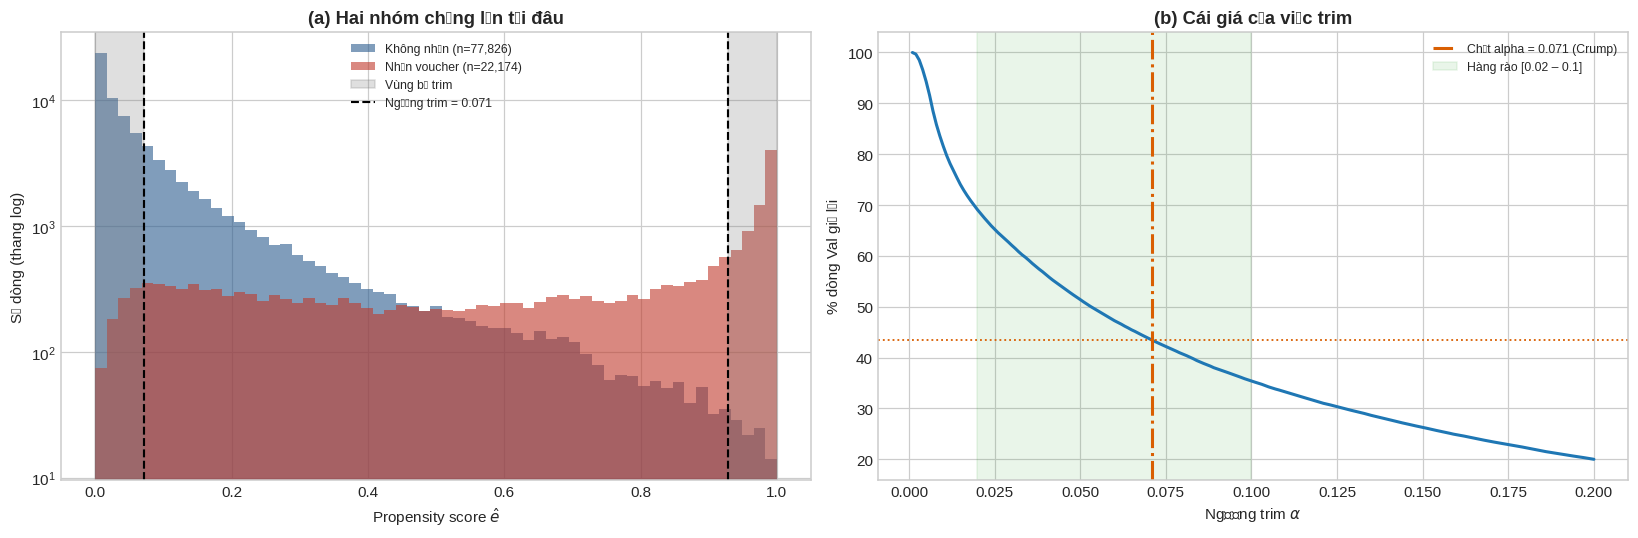

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bins = np.linspace(0, 1, 60)
axes[0].hist(e_raw_val[W_val == 0], bins=bins, alpha=0.60, color='#2b5c8f',
             label=f'Không nhận (n={(W_val==0).sum():,})')
axes[0].hist(e_raw_val[W_val == 1], bins=bins, alpha=0.60, color='#c0392b',
             label=f'Nhận voucher (n={(W_val==1).sum():,})')
axes[0].axvspan(0, E_ALPHA, color='gray', alpha=0.25)
axes[0].axvspan(1 - E_ALPHA, 1, color='gray', alpha=0.25, label='Vùng bị trim')
axes[0].axvline(E_ALPHA, color='black', ls='--', lw=1.4)
axes[0].axvline(1 - E_ALPHA, color='black', ls='--', lw=1.4,
                label=f'Ngưỡng trim = {E_ALPHA}')
axes[0].set_yscale('log')
axes[0].set_xlabel(r'Propensity score $\hat{e}$')
axes[0].set_ylabel('Số dòng (thang log)')
axes[0].set_title('(a) Hai nhóm chồng lấn tới đâu')
axes[0].legend(fontsize=8)

luoi_a = np.linspace(0.001, 0.20, 200)
ti_le = [((e_raw_val >= a) & (e_raw_val <= 1 - a)).mean() * 100 for a in luoi_a]
axes[1].plot(luoi_a, ti_le, color='#1f77b4', lw=2)
axes[1].axvline(E_ALPHA, color='#d95f02', ls='-.', lw=2,
                label=f'Chốt alpha = {E_ALPHA} (Crump)')
axes[1].axvspan(ALPHA_MIN, ALPHA_MAX, color='#2ca02c', alpha=0.10,
                label=f'Hàng rào [{ALPHA_MIN} – {ALPHA_MAX}]')
axes[1].axhline(((e_raw_val >= E_ALPHA) & (e_raw_val <= 1 - E_ALPHA)).mean() * 100,
                color='#d95f02', ls=':', lw=1.2)
axes[1].set_xlabel(r'Ngưỡng trim $\alpha$')
axes[1].set_ylabel('% dòng Val giữ lại')
axes[1].set_title('(b) Cái giá của việc trim')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '11b_overlap_val.png'), bbox_inches='tight')
plt.show()

### Bước 10 — Trim, và phát biểu lại estimand cho đúng

Từ đây, mọi con số ở Phần 2, Phần 4 và Phần 5 đều tính trên **tập con overlap** của Val, chứ không phải toàn bộ Val.

> **Estimand đã đổi.** Trước khi trim, đại lượng nhắm tới là $E_{P_{val}}[\tau(X)]$ — hiệu ứng trung bình trên toàn quần thể Val. Sau khi trim, nó là
> $$E_{P_{val}}\big[\tau(X) \;\big|\; \alpha \le e(X) \le 1-\alpha\big]$$
> tức **ATE trên vùng overlap**: trung bình chỉ lấy trên nhóm khách hàng mà cả hai khả năng — được phát và không được phát voucher — đều thực sự xảy ra trong dữ liệu.
>
> Đây không phải một xấp xỉ tệ hơn của đại lượng cũ, mà là **một đại lượng khác**, và là đại lượng duy nhất trong hai cái mà dữ liệu này thật sự trả lời được. Với những khách hàng có $\hat e$ sát 0, dữ liệu gần như không chứa trường hợp đối chứng nào; mọi con số nói về họ đều là ngoại suy của mô hình chứ không phải bằng chứng.
>
> Hệ quả phải nhớ: **thứ hạng mô hình trong notebook này là thứ hạng trên vùng overlap.** Phán quyết cuối vẫn thuộc về Qini đo trên tập RCT ở notebook 04, nơi việc phát voucher là ngẫu nhiên nên $e \equiv 0{,}5$ và không cần trim gì cả.

Còn phía **huấn luyện** thì chỉ clip chứ không trim: mô hình vẫn phải học trên toàn bộ không gian đặc trưng vì lúc phục vụ nó bị hỏi về mọi khách hàng, kể cả người nằm ngoài vùng overlap. Trim chỉ áp cho **thước đo**, nơi ta cần nhãn đáng tin. Ghi nhận đây là một lựa chọn có chủ đích, không phải sơ suất.

In [11]:
dr_full, e_val = dr_from_nuisance(W_val, Y_val, e_raw_val, mu0_val, mu1_val, E_CLIP)

overlap = (e_raw_val >= E_ALPHA) & (e_raw_val <= 1 - E_ALPHA)

dr_ov = dr_full[overlap]          # pseudo-outcome trên vùng overlap, CHƯA winsorize
X_val_ov = X_val[overlap]
W_val_ov = W_val[overlap]
Y_val_ov = Y_val[overlap]

print(f'Val ban đầu      : {len(dr_full):>8,} dòng')
print(f'Sau khi trim     : {len(dr_ov):>8,} dòng  ({overlap.mean()*100:.2f}%)')
print(f'  bị loại        : {(~overlap).sum():>8,} dòng  '
      f'(treat {int((W_val[~overlap]==1).sum()):,} | control {int((W_val[~overlap]==0).sum()):,})')
print()

display(pd.DataFrame([
    {'Tập': 'Toàn bộ Val (chỉ clip)', 'n': len(dr_full),
     'Trung bình Ỹ': dr_full.mean(), 'Độ lệch chuẩn': dr_full.std(),
     'Nhỏ nhất': dr_full.min(), 'Lớn nhất': dr_full.max()},
    {'Tập': 'Vùng overlap (đã trim)', 'n': len(dr_ov),
     'Trung bình Ỹ': dr_ov.mean(), 'Độ lệch chuẩn': dr_ov.std(),
     'Nhỏ nhất': dr_ov.min(), 'Lớn nhất': dr_ov.max()},
]).round(4))

Val ban đầu      :  100,000 dòng
Sau khi trim     :   43,431 dòng  (43.43%)
  bị loại        :   56,569 dòng  (treat 8,097 | control 48,472)



,Tập,n,Trung bình Ỹ,Độ lệch chuẩn,Nhỏ nhất,Lớn nhất
0,Toàn bộ Val (chỉ clip),100000,0.0052,0.3336,-13.8155,13.9989
1,Vùng overlap (đã trim),43431,0.0044,0.3728,-12.0474,13.3977


### Bước 11 — Winsorize $\tilde Y$ ở phân vị 0,5% / 99,5%

Trim đã bỏ nguồn phương sai lớn nhất, nhưng vẫn còn vài dòng có $\hat e$ ngay sát ngưỡng cộng với $Y - \hat\mu$ lớn, cho ra $\tilde Y$ cỡ hàng chục. Trong một diện tích tích lũy, một điểm như vậy đủ sức tự mình quyết định thứ hạng của cả mô hình.

Winsorize kéo 0,5% đuôi mỗi bên về đúng phân vị đó. Khác với trim, nó **không bỏ dòng nào** — chỉ hạ độ lớn của nhãn.

> **Một cảnh báo phải nói thẳng, nếu không sẽ thành lỗi nặng.**
>
> Winsorize làm **lệch trung bình**. Trên bộ dữ liệu này, phần lớn giá trị của ước lượng ATE nằm chính ở hai cái đuôi — đó là bản chất của ước lượng kiểu IPW khi overlap kém. Cắt đuôi đi thì con số ATE tụt xuống rõ rệt, và ô lệnh dưới đây in ra đúng mức tụt đó thay vì giấu.
>
> Nên phân vai dứt khoát:
>
> | Biến | Là gì | Dùng vào việc gì | **Không** dùng vào việc gì |
> |---|---|---|---|
> | `dr_ov` | Đã trim, **chưa** winsorize | Ước lượng **mức** ATE trên vùng overlap (Bước 12) | — |
> | `dr_val` | Đã trim **và** winsorize | Nhãn cho thước đo **xếp hạng** (Bước 13 trở đi) | Không bao giờ dùng để báo cáo mức ATE |
>
> Việc này hợp lệ vì DR-AUUC chỉ hỏi *"nhóm được mô hình xếp cao có $\tilde Y$ trung bình cao hơn không"*. Một phép biến đổi đơn điệu, cùng áp lên mọi mô hình như nhau, không làm hỏng phép so sánh đó — trong khi nó chặn được chuyện một dòng duy nhất lật ngược cả bảng xếp hạng.

,Dãy,Trung bình (pp),Độ lệch chuẩn,Nhỏ nhất,Lớn nhất
0,dr_ov — chưa winsorize,0.4440,0.3728,-12.0474,13.3977
1,dr_val — đã winsorize,0.2255,0.2012,-1.2577,1.5476


Cận winsorize        : [-1.258 ; 1.548]
Số điểm bị kéo về cận: 436 / 43,431  (1.00%)
Độ lệch chuẩn giảm   : 0.373 -> 0.201 (46%)
Trung bình bị kéo    : +0.444 pp -> +0.225 pp
  => đúng như cảnh báo ở trên: dr_val KHÔNG dùng để báo cáo mức ATE.


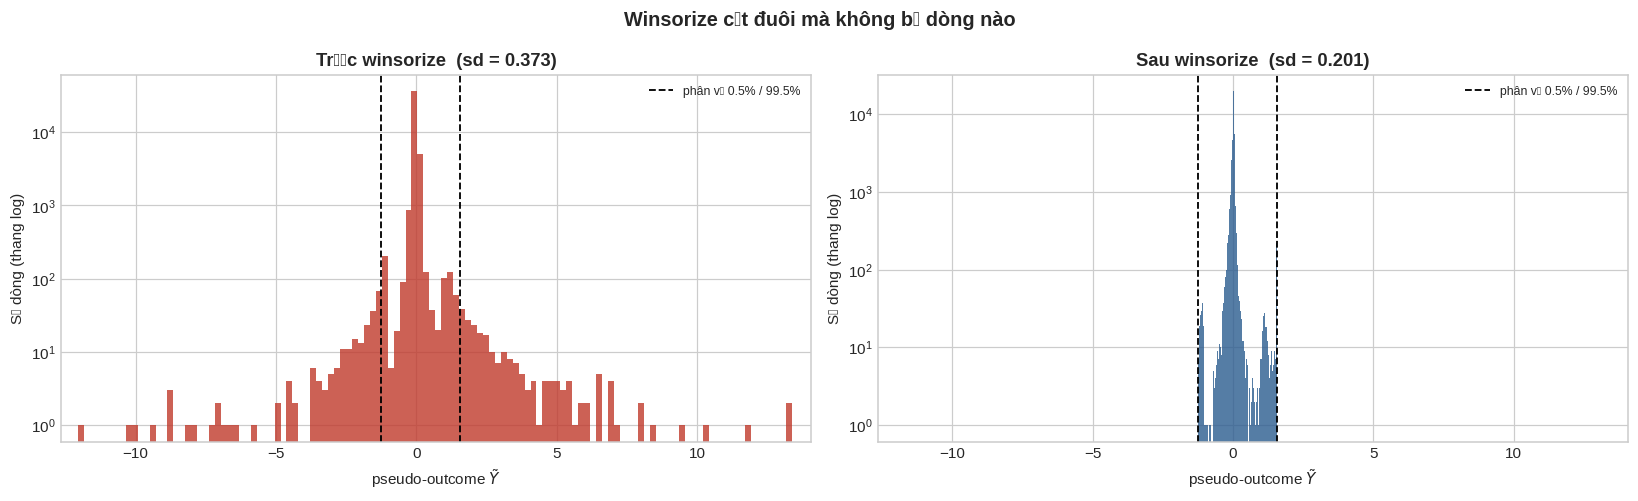

In [12]:
def winsorize(v, p=WINSOR_P):
    '''Kéo p% đuôi mỗi bên về đúng phân vị đó. Trả về (dãy đã cắt, cận dưới, cận trên).'''
    lo, hi = np.percentile(v, [p, 100 - p])
    return np.clip(v, lo, hi), float(lo), float(hi)


dr_val, WIN_LO, WIN_HI = winsorize(dr_ov)
n_doi = int((dr_ov < WIN_LO).sum() + (dr_ov > WIN_HI).sum())

display(pd.DataFrame([
    {'Dãy': 'dr_ov — chưa winsorize', 'Trung bình (pp)': dr_ov.mean() * 100,
     'Độ lệch chuẩn': dr_ov.std(), 'Nhỏ nhất': dr_ov.min(), 'Lớn nhất': dr_ov.max()},
    {'Dãy': 'dr_val — đã winsorize', 'Trung bình (pp)': dr_val.mean() * 100,
     'Độ lệch chuẩn': dr_val.std(), 'Nhỏ nhất': dr_val.min(), 'Lớn nhất': dr_val.max()},
]).round(4))

print(f'Cận winsorize        : [{WIN_LO:.3f} ; {WIN_HI:.3f}]')
print(f'Số điểm bị kéo về cận: {n_doi:,} / {len(dr_ov):,}  ({n_doi/len(dr_ov)*100:.2f}%)')
print(f'Độ lệch chuẩn giảm   : {dr_ov.std():.3f} -> {dr_val.std():.3f} '
      f'({(1 - dr_val.std()/dr_ov.std())*100:.0f}%)')
print(f'Trung bình bị kéo    : {dr_ov.mean()*100:+.3f} pp -> {dr_val.mean()*100:+.3f} pp')
print('  => đúng như cảnh báo ở trên: dr_val KHÔNG dùng để báo cáo mức ATE.')

# --- biểu đồ trước/sau ------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))

for ax, (v, nhan, mau) in zip(axes, [(dr_ov, 'Trước winsorize', '#c0392b'),
                                     (dr_val, 'Sau winsorize', '#2b5c8f')]):
    ax.hist(v, bins=120, color=mau, alpha=0.8)
    ax.axvline(WIN_LO, color='black', ls='--', lw=1.2)
    ax.axvline(WIN_HI, color='black', ls='--', lw=1.2,
               label=f'phân vị {WINSOR_P}% / {100-WINSOR_P}%')
    ax.set_yscale('log')
    ax.set_xlim(min(dr_ov.min(), -1) * 1.05, max(dr_ov.max(), 1) * 1.05)
    ax.set_xlabel(r'pseudo-outcome $\tilde{Y}$')
    ax.set_ylabel('Số dòng (thang log)')
    ax.set_title(f'{nhan}  (sd = {v.std():.3f})')
    ax.legend(fontsize=8)

plt.suptitle('Winsorize cắt đuôi mà không bỏ dòng nào', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '11c_winsorize_dr.png'), bbox_inches='tight')
plt.show()

### Bước 12 — Hiệu chỉnh doubly robust làm thay đổi ước lượng bao nhiêu?

Trung bình của `dr_ov` chính là **ước lượng doubly robust cho ATE trên vùng overlap**.

So nó với ước lượng ngây thơ tính trên **đúng tập con đó** — không phải trên toàn bộ Val. Đây là chi tiết bản trước làm chưa chặt: sau khi trim thì hai vế phải cùng đứng trên cùng một quần thể, nếu không thì một phần chênh lệch đến từ việc đổi quần thể chứ không phải từ hiệu chỉnh.

> **Lưu ý về phạm vi của bước này.** Ở đây chỉ đo *hiệu chỉnh làm thay đổi con số bao nhiêu*, **không** kết luận con số nào đúng. Muốn biết ước lượng đã hiệu chỉnh có đáng tin không thì phải đối chiếu với dữ liệu RCT — việc đó để Phần 6 làm, sau khi đã có mô hình.

In [13]:
ate_naive_ov = Y_val_ov[W_val_ov == 1].mean() - Y_val_ov[W_val_ov == 0].mean()
ate_naive_all = Y_val[W_val == 1].mean() - Y_val[W_val == 0].mean()

ate_dr = dr_ov.mean()                       # con số chính — trên vùng overlap, chưa winsorize
se_dr = dr_ov.std() / np.sqrt(len(dr_ov))
ate_dr_all = dr_full.mean()                 # để tham chiếu: chưa trim, chỉ clip

display(pd.DataFrame([
    ('Ngây thơ — toàn bộ Val', ate_naive_all * 100, None, None),
    ('Ngây thơ — vùng overlap', ate_naive_ov * 100, None, None),
    ('Doubly robust — toàn bộ Val (chỉ clip)', ate_dr_all * 100, None, None),
    ('Doubly robust — vùng overlap (đã trim)', ate_dr * 100,
     (ate_dr - 1.96 * se_dr) * 100, (ate_dr + 1.96 * se_dr) * 100),
], columns=['Ước lượng', 'ATE (pp)', 'KTC dưới', 'KTC trên']).round(3))

print(f'Trên cùng vùng overlap, hiệu chỉnh kéo ước lượng từ {ate_naive_ov*100:.3f} pp '
      f'xuống {ate_dr*100:.3f} pp')
print(f'Mức thay đổi: {abs(ate_dr - ate_naive_ov)*100:.3f} pp '
      f'({(1 - ate_dr/ate_naive_ov)*100:.1f}% so với ước lượng ngây thơ)')
print(f'\nTrim còn kéo ước lượng DR từ {ate_dr_all*100:.3f} pp (chỉ clip) '
      f'xuống {ate_dr*100:.3f} pp (đã trim).')
print('Hai con số này là hai estimand khác nhau, không phải cái nào sai — xem Bước 10.')

,Ước lượng,ATE (pp),KTC dưới,KTC trên
0,Ngây thơ — toàn bộ Val,4.720,NaN,NaN
1,Ngây thơ — vùng overlap,1.998,NaN,NaN
2,Doubly robust — toàn bộ Val (chỉ clip),0.524,NaN,NaN
3,Doubly robust — vùng overlap (đã trim),0.444,0.093,0.795


Trên cùng vùng overlap, hiệu chỉnh kéo ước lượng từ 1.998 pp xuống 0.444 pp
Mức thay đổi: 1.554 pp (77.8% so với ước lượng ngây thơ)

Trim còn kéo ước lượng DR từ 0.524 pp (chỉ clip) xuống 0.444 pp (đã trim).
Hai con số này là hai estimand khác nhau, không phải cái nào sai — xem Bước 10.


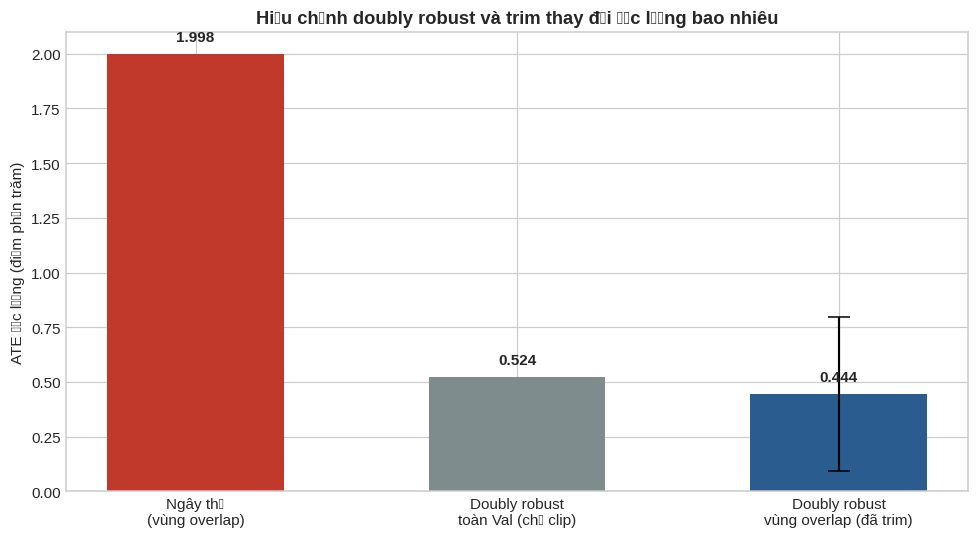

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
names = ['Ngây thơ\n(vùng overlap)', 'Doubly robust\ntoàn Val (chỉ clip)',
         'Doubly robust\nvùng overlap (đã trim)']
vals = [ate_naive_ov * 100, ate_dr_all * 100, ate_dr * 100]

bars = ax.bar(names, vals, color=['#c0392b', '#7f8c8d', '#2b5c8f'], width=0.55)
ax.errorbar(2, ate_dr * 100, yerr=1.96 * se_dr * 100, fmt='none',
            ecolor='black', capsize=7, lw=1.4)
ax.set_ylabel('ATE ước lượng (điểm phần trăm)')
ax.set_title('Hiệu chỉnh doubly robust và trim thay đổi ước lượng bao nhiêu')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + max(vals) * 0.03,
            f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '11_hieu_chinh_dr.png'), bbox_inches='tight')
plt.show()

### Bước 13 — Thước đo tinh chỉnh: DR-AUUC

Đây là thay đổi trọng tâm. Xây đúng theo mô tả của mentor:

1. Sắp khách hàng **giảm dần theo $\hat\tau$** mô hình dự đoán
2. Lấy **trung bình tích lũy** của $\tilde Y$ theo thứ tự đó
3. Tính **diện tích** giữa đường cong và đường chéo ngẫu nhiên

Viết ra công thức: gọi $c(q)$ là trung bình $\tilde Y$ của $q$ phần đầu bảng, đường cong dùng để tính diện tích là $g(q) = q\,c(q)$ — tức tổng uplift thu được nếu chỉ phát voucher cho $q$ phần dân số, chia cho cỡ mẫu.

$$g(q) = \frac{1}{n}\sum_{i \le qn} \tilde Y_{(i)}, \qquad
\text{DR-AUUC}_{\text{thô}} = \int_0^1 g(q)\,dq \;-\; \tfrac{1}{2}g(1)$$

Số hạng $\tfrac12 g(1)$ là diện tích dưới đường chéo — thứ một xếp hạng ngẫu nhiên thu được. Trừ nó đi thì còn lại đúng phần **do việc xếp hạng mang lại**.

**Vì sao cách này chữa được bệnh của DR-MSE.** DR-MSE cộng thêm $E[\text{Var}(\tilde Y \mid X)]$ — một hằng số khổng lồ giống hệt nhau ở mọi mô hình. DR-AUUC thì tuyến tính theo $\tilde Y$, nên phần nhiễu của $\tilde Y$ **triệt tiêu khi lấy trung bình tích lũy** thay vì bị bình phương lên rồi cộng dồn. Cái còn lại đúng là thứ cần đo: nhóm mô hình chấm điểm cao có uplift thật sự cao hơn không.

**Chuẩn hóa.** Diện tích thô cỡ $10^{-3}$, đúng nhưng khó đọc. Chia cho diện tích của xếp hạng **biết trước đáp án** — tức sắp theo chính $\tilde Y$ — để quy về thang quen thuộc: ngẫu nhiên $\approx 0$, biết trước $= 1$. Đây đúng là cách notebook 04 chuẩn hóa hệ số Qini, nên hai con số đọc được trên cùng một thang.

**Ba thước đo, ba vai trò.** Đừng lẫn:

| Hàm | Vai trò | Ghi ở đâu |
|---|---|---|
| `dr_qini` | **Hàm mục tiêu Optuna** — càng cao càng tốt | MLflow + bảng xếp hạng |
| `dr_policy_value` | Diễn giải được: uplift trung bình của nhóm top 20% | MLflow, để đọc cho dễ |
| `dr_mse` | **Thước đo cũ, giữ lại làm tang chứng** — Bước 24 dùng nó để cho thấy nó xếp hạng ngược | MLflow |

In [15]:
def _thu_tu(score, seed=SEED):
    '''Sắp giảm dần theo score, phá thế hòa ngẫu nhiên có seed.
       Cùng cách làm với notebook 04: nhiều mô hình cho CATE trùng nhau hàng loạt,
       để argsort tự xử thì thứ tự phụ thuộc thứ tự dòng trong file.'''
    n = len(score)
    rng = np.random.RandomState(seed)
    return np.lexsort((rng.rand(n), -np.asarray(score, dtype=float)))


def dr_gain_curve(score, dr=None, seed=SEED):
    '''(x = tỉ lệ dân số được nhắm, g = uplift tích lũy trên mỗi người).
       Có kèm điểm gốc (0, 0): nhắm 0% dân số thì thu được 0 uplift. Nghe như thừa,
       nhưng thiếu nó thì phép lấy diện tích lệch một lượng cỡ 1/n và phép thử
       "xếp hạng ngược phải cho đúng số đối" ở Bước 14 không còn khớp chính xác.'''
    dr = dr_val if dr is None else dr
    order = _thu_tu(score, seed)
    n = len(dr)
    x = np.concatenate([[0.0], np.arange(1, n + 1) / n])
    g = np.concatenate([[0.0], np.cumsum(np.asarray(dr, dtype=float)[order]) / n])
    return x, g


def dr_auuc_tho(score, dr=None, seed=SEED):
    '''Diện tích giữa đường cong và đường chéo ngẫu nhiên — chưa chuẩn hóa.'''
    x, g = dr_gain_curve(score, dr, seed)
    return float(TRAPZ(g, x) - 0.5 * g[-1])


def dr_qini(score, dr=None, seed=SEED):
    '''THƯỚC ĐO CHÍNH. Chuẩn hóa theo xếp hạng biết trước. Ngẫu nhiên ~ 0, biết trước = 1.'''
    dr = dr_val if dr is None else dr
    tran = dr_auuc_tho(dr, dr, seed)          # trần trên: sắp theo chính Ỹ
    return dr_auuc_tho(score, dr, seed) / tran if tran > 0 else np.nan


def dr_policy_value(score, dr=None, top_frac=0.2, seed=SEED):
    '''Uplift trung bình của nhóm top-k theo CATE dự đoán — càng cao càng tốt.'''
    dr = dr_val if dr is None else dr
    order = _thu_tu(score, seed)
    k = max(1, int(round(top_frac * len(dr))))
    return float(np.asarray(dr, dtype=float)[order[:k]].mean())


def dr_mse(score, dr=None):
    '''Thước đo CŨ — giữ lại chỉ để ghi vết và để Bước 24 chứng minh vì sao phải bỏ nó.'''
    dr = dr_val if dr is None else dr
    return float(np.mean((np.asarray(score, dtype=float) - dr) ** 2))


print('Đã định nghĩa dr_qini (chính), dr_policy_value, dr_mse (tham chiếu)')
print(f'Thước đo tính trên {len(dr_val):,} dòng thuộc vùng overlap của Val')

Đã định nghĩa dr_qini (chính), dr_policy_value, dr_mse (tham chiếu)
Thước đo tính trên 43,431 dòng thuộc vùng overlap của Val


### Bước 14 — Kiểm chứng thước đo trước khi tin nó

Đúng tinh thần Phần 2 của notebook 04: viết metric xong thì thử ngược bằng những trường hợp đã biết trước đáp án. Nếu công thức sai thì mọi kết luận sau đó sai theo, mà cái sai đó rất khó phát hiện vì bảng kết quả vẫn in ra những con số trông hợp lý.

Bốn phép thử:

1. **Xếp hạng biết trước $= 1{,}0$** — đúng theo định nghĩa chuẩn hóa. Chỉ xác nhận phần chuẩn hóa cài đúng.
2. **Xếp hạng ngược lại $= -1{,}0$** — đây mới là phép thử thật cho phần chuẩn hóa: đối xứng qua 0 chỉ đúng nếu công thức diện tích đúng.
3. **Xếp hạng ngẫu nhiên $\approx 0$** — lấy trung bình trên 20 lần bốc độc lập, vì một lần bốc lẻ có dao động riêng của nó.
4. **Pha nhiễu dần thì phải giảm đơn điệu** — phép thử nặng ký nhất, vì nó không dựa vào trường hợp biên nào.

Dùng `assert` chứ không chỉ in ra màn hình, để lần chạy sau nếu metric hỏng thì notebook dừng ngay tại đây thay vì đẻ ra một bảng kết quả sai.

In [16]:
rng_kc = np.random.RandomState(SEED)

# 1 & 2 — hai trường hợp biên
q_biet_truoc = dr_qini(dr_val)
q_nguoc = dr_qini(-dr_val)

# 3 — 20 lần bốc ngẫu nhiên độc lập
q_rnd_nhieu_lan = np.array([dr_qini(rng_kc.randn(len(dr_val))) for _ in range(20)])
q_rnd_tb, q_rnd_sd = q_rnd_nhieu_lan.mean(), q_rnd_nhieu_lan.std()

# 4 — pha nhiễu dần vào xếp hạng biết trước
muc_nhieu = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
nhieu = rng_kc.randn(len(dr_val))
thang = dr_val.std()
q_theo_nhieu = [dr_qini(dr_val + m * thang * nhieu) for m in muc_nhieu]
giam_don_dieu = bool(np.all(np.diff(q_theo_nhieu) <= 1e-12))

print('Qini_DR khi pha nhiễu dần:')
print(pd.DataFrame({'Biên độ nhiễu': muc_nhieu,
                    'Qini_DR': np.round(q_theo_nhieu, 4)}).to_string(index=False))
print(f'\n20 lần xếp hạng ngẫu nhiên: trung bình {q_rnd_tb:+.4f} | '
      f'độ lệch chuẩn {q_rnd_sd:.4f}')

kiem_chung = pd.DataFrame([
    {'Phép thử': '1. Xếp hạng biết trước = 1,0',
     'Kết quả': f'{q_biet_truoc:.6f}', 'Đạt': abs(q_biet_truoc - 1.0) < 1e-9},
    {'Phép thử': '2. Xếp hạng ngược = -1,0',
     'Kết quả': f'{q_nguoc:.6f}', 'Đạt': abs(q_nguoc + 1.0) < 1e-9},
    {'Phép thử': '3. Ngẫu nhiên ~ 0 (TB 20 lần)',
     'Kết quả': f'{q_rnd_tb:+.4f} ± {q_rnd_sd:.4f}', 'Đạt': abs(q_rnd_tb) < 0.05},
    {'Phép thử': '4. Giảm đơn điệu theo nhiễu',
     'Kết quả': f'{q_theo_nhieu[0]:.3f} -> {q_theo_nhieu[-1]:.3f}', 'Đạt': giam_don_dieu},
])
display(kiem_chung)

assert kiem_chung['Đạt'].all(), 'Có phép kiểm chứng không đạt — sửa công thức trước khi đi tiếp'
print('\n✅ Thước đo qua cả bốn phép kiểm chứng, dùng được làm hàm mục tiêu Optuna.')

# Mốc tham chiếu để đọc bảng kết quả ở Phần 4
baseline_qini = float(q_rnd_tb)
baseline_pv = dr_policy_value(rng_kc.randn(len(dr_val)))
baseline_mse = dr_mse(np.full(len(dr_val), ate_dr))
print(f'\nMốc tham chiếu — Qini_DR của xếp hạng ngẫu nhiên : {baseline_qini:+.4f}')
print(f'Mốc tham chiếu — policy value ngẫu nhiên         : {baseline_pv:+.6f}')
print(f'Mốc tham chiếu — DR-MSE của dự đoán hằng số      : {baseline_mse:.6f}')

Qini_DR khi pha nhiễu dần:
 Biên độ nhiễu  Qini_DR
          0.00   1.0000
          0.25   0.8836
          0.50   0.7810
          1.00   0.6749
          2.00   0.5783
          4.00   0.4170
          8.00   0.2387

20 lần xếp hạng ngẫu nhiên: trung bình +0.0018 | độ lệch chuẩn 0.0097


,Phép thử,Kết quả,Đạt
0,"1. Xếp hạng biết trước = 1,0",1.000000,True
1,"2. Xếp hạng ngược = -1,0",-1.000000,True
2,3. Ngẫu nhiên ~ 0 (TB 20 lần),+0.0018 ± 0.0097,True
3,4. Giảm đơn điệu theo nhiễu,1.000 -> 0.239,True



✅ Thước đo qua cả bốn phép kiểm chứng, dùng được làm hàm mục tiêu Optuna.

Mốc tham chiếu — Qini_DR của xếp hạng ngẫu nhiên : +0.0018
Mốc tham chiếu — policy value ngẫu nhiên         : +0.002365
Mốc tham chiếu — DR-MSE của dự đoán hằng số      : 0.040503


---
# Phần 3 — Sáu mô hình

Tất cả bọc chung một giao diện `fit(X, W, Y)` và `predict_cate(X)` để vòng tinh chỉnh gọi thống nhất.

| Mô hình | Vai trò |
|---|---|
| S-Learner | Baseline — một mô hình duy nhất, coi W như một đặc trưng |
| T-Learner | Baseline — hai mô hình riêng cho hai nhóm |
| DR-Learner | Nhân vật chính 1 — pseudo-outcome doubly robust (Kennedy 2020) |
| LinearDML | Tầng cuối tuyến tính, hệ số diễn giải được |
| NonParamDML | Tầng cuối linh hoạt, bắt được bề mặt CATE phức tạp |
| CausalForestDML | Khoảng tin cậy hợp lệ nhờ honest splitting |

Hai baseline rất rẻ mà rất đáng có: không có mốc so sánh thì không chứng minh được tính doubly robust mang lại lợi ích gì.

### Bước 15 — Hai baseline: S-Learner và T-Learner

In [17]:
class SLearner:
    '''Một mô hình duy nhất trên [X, W]. CATE = f(X,1) - f(X,0).'''
    def __init__(self, **params):
        self.params = dict(params, random_state=SEED, verbose=-1)

    def fit(self, X, W, Y):
        self.model = lgb.LGBMClassifier(**self.params).fit(
            np.column_stack([X, W]), Y)
        return self

    def predict_cate(self, X):
        n = len(X)
        p1 = self.model.predict_proba(np.column_stack([X, np.ones(n)]))[:, 1]
        p0 = self.model.predict_proba(np.column_stack([X, np.zeros(n)]))[:, 1]
        return p1 - p0


class TLearner:
    '''Hai mô hình riêng cho nhóm treatment và control. CATE = f1(X) - f0(X).'''
    def __init__(self, **params):
        self.params = dict(params, random_state=SEED, verbose=-1)

    def fit(self, X, W, Y):
        self.m1 = lgb.LGBMClassifier(**self.params).fit(X[W == 1], Y[W == 1])
        self.m0 = lgb.LGBMClassifier(**self.params).fit(X[W == 0], Y[W == 0])
        return self

    def predict_cate(self, X):
        return self.m1.predict_proba(X)[:, 1] - self.m0.predict_proba(X)[:, 1]

### Bước 16 — DR-Learner

Hai tầng. Tầng một dựng pseudo-outcome doubly robust bằng cross-fitting — dùng lại đúng hàm đã viết ở Bước 6, nhưng lần này chạy trên tập huấn luyện và với ngưỡng cắt `E_CLIP` đã chốt ở Bước 8. Tầng hai hồi quy pseudo-outcome đó lên không gian đặc trưng.

Chỉ tinh chỉnh siêu tham số của **tầng cuối**. Tham số của ba mô hình phụ giữ cố định, vì nếu tinh chỉnh cả hai tầng thì không gian tìm kiếm phình ra quá lớn so với ngân sách trial.

Nhắc lại lựa chọn ở Bước 10: phía huấn luyện **chỉ clip, không trim**. Mô hình vẫn phải học trên toàn bộ không gian đặc trưng vì lúc phục vụ nó bị hỏi về mọi khách hàng.

In [18]:
class DRLearner:
    '''Kennedy 2020 — hồi quy pseudo-outcome doubly robust.'''
    def __init__(self, n_folds=5, **params):
        self.n_folds = n_folds
        self.params = dict(params, random_state=SEED, verbose=-1)

    def fit(self, X, W, Y):
        dr_train, *_ = compute_dr_scores(X, W, Y, n_folds=self.n_folds)
        self.model = lgb.LGBMRegressor(**self.params).fit(X, dr_train)
        return self

    def predict_cate(self, X):
        return self.model.predict(X)

### Bước 17 — Ba mô hình DML từ EconML

In [19]:
class EconMLWrapper:
    '''Bọc estimator của EconML về cùng giao diện fit/predict_cate.'''
    def __init__(self, estimator):
        self.est = estimator

    def fit(self, X, W, Y):
        self.est.fit(Y, W, X=X)
        return self

    def predict_cate(self, X):
        return np.asarray(self.est.effect(X)).ravel()


def make_nuisance(p):
    '''Cặp mô hình phụ cho các estimator DML.'''
    common = dict(n_estimators=p['nuisance_n_estimators'], learning_rate=0.05,
                  max_depth=p['nuisance_max_depth'], random_state=SEED, verbose=-1)
    return lgb.LGBMRegressor(**common), lgb.LGBMClassifier(**common)


def build_model(name, p):
    '''Tạo mô hình từ tên và bộ siêu tham số.'''
    if name == 'SLearner':
        return SLearner(n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                        max_depth=p['max_depth'], min_child_samples=p['min_child_samples'])
    if name == 'TLearner':
        return TLearner(n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                        max_depth=p['max_depth'], min_child_samples=p['min_child_samples'])
    if name == 'DRLearner':
        return DRLearner(n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                         max_depth=p['max_depth'], min_child_samples=p['min_child_samples'])

    model_y, model_t = make_nuisance(p)
    if name == 'LinearDML':
        return EconMLWrapper(LinearDML(
            model_y=model_y, model_t=model_t, discrete_treatment=True,
            cv=p['cv'], random_state=SEED))
    if name == 'NonParamDML':
        return EconMLWrapper(NonParamDML(
            model_y=model_y, model_t=model_t,
            model_final=lgb.LGBMRegressor(
                n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                max_depth=p['max_depth'], min_child_samples=p['min_child_samples'],
                random_state=SEED, verbose=-1),
            discrete_treatment=True, cv=p['cv'], random_state=SEED))
    if name == 'CausalForestDML':
        return EconMLWrapper(CausalForestDML(
            model_y=model_y, model_t=model_t, discrete_treatment=True,
            n_estimators=p['cf_n_estimators'], min_samples_leaf=p['cf_min_samples_leaf'],
            max_depth=p['cf_max_depth'], cv=p['cv'], random_state=SEED))

    raise ValueError(f'Không biết mô hình: {name}')

---
# Phần 4 — Tinh chỉnh bằng Optuna

Mỗi trial: lấy một bộ siêu tham số, huấn luyện trên tập tinh chỉnh, dự đoán CATE trên **vùng overlap của tập Val**, chấm bằng `dr_qini`. Optuna dùng kết quả các trial trước để đề xuất bộ tham số tiếp theo.

Khác bản trước ở hai chỗ: hàm mục tiêu đổi từ DR-MSE sang DR-AUUC, và hướng tối ưu đổi từ `minimize` sang **`maximize`**.

Mỗi trial là một run trên MLflow, ghi đầy đủ siêu tham số và cả bốn thước đo — kể cả DR-MSE, để so được với bản trước.

### Bước 18 — Không gian tìm kiếm

In [20]:
def suggest_params(trial, name):
    p = {}
    if name in ('SLearner', 'TLearner', 'DRLearner', 'NonParamDML'):
        p['n_estimators'] = trial.suggest_int('n_estimators', 100, 400, step=50)
        p['learning_rate'] = trial.suggest_float('learning_rate', 0.01, 0.15, log=True)
        p['max_depth'] = trial.suggest_int('max_depth', 3, 8)
        p['min_child_samples'] = trial.suggest_int('min_child_samples', 20, 200, log=True)
    if name in ('LinearDML', 'NonParamDML', 'CausalForestDML'):
        p['nuisance_n_estimators'] = trial.suggest_int('nuisance_n_estimators', 100, 300, step=50)
        p['nuisance_max_depth'] = trial.suggest_int('nuisance_max_depth', 3, 7)
        p['cv'] = trial.suggest_categorical('cv', [3, 5])
    if name == 'CausalForestDML':
        # EconML yêu cầu n_estimators chia hết cho subforest_size (mặc định 4),
        # nên chỉ đưa vào các giá trị hợp lệ thay vì quét theo bước tùy ý.
        p['cf_n_estimators'] = trial.suggest_categorical('cf_n_estimators', [100, 200, 400])
        p['cf_min_samples_leaf'] = trial.suggest_int('cf_min_samples_leaf', 20, 200, log=True)
        p['cf_max_depth'] = trial.suggest_int('cf_max_depth', 4, 10)
    return p

### Bước 19 — Vòng tinh chỉnh

Trial nào lỗi thì trả về $-\infty$ thay vì làm hỏng cả study — một bộ tham số xấu không nên chặn toàn bộ quá trình tìm kiếm. (Bản trước trả về $+\infty$ vì khi đó đang tối thiểu hóa.)

Một chi tiết nhỏ nhưng tiết kiệm hẳn một vòng huấn luyện: hàm giữ lại **mảng CATE của trial tốt nhất**. Phần 5 cần đúng mảng đó để bootstrap, và nhờ vậy không phải huấn luyện lại 6 mô hình chỉ để lấy dự đoán.

In [21]:
def tune_model(name, n_trials):
    print(f'\n{"="*62}\n  {name} — {n_trials} trial\n{"="*62}')
    history = []
    giu_lai = {'q': -np.inf, 'cate': None, 'trial': None}   # CATE của trial tốt nhất

    def objective(trial):
        p = suggest_params(trial, name)
        t0 = time.time()
        try:
            model = build_model(name, p).fit(X_tune, W_tune, Y_tune)
            cate = model.predict_cate(X_val_ov)          # chỉ chấm trên vùng overlap
            if not np.all(np.isfinite(cate)):
                raise ValueError('CATE chứa giá trị không hữu hạn')
            q = dr_qini(cate)
            auuc = dr_auuc_tho(cate)
            pv = dr_policy_value(cate)
            mse = dr_mse(cate)
            status = 'ok'
        except Exception as exc:
            print(f'  trial {trial.number}: LỖI — {type(exc).__name__}: {exc}')
            q, auuc, pv, mse = -np.inf, float('nan'), float('nan'), float('inf')
            cate, status = None, f'lỗi: {type(exc).__name__}'

        elapsed = time.time() - t0

        if np.isfinite(q) and q > giu_lai['q']:
            giu_lai.update(q=q, cate=cate, trial=trial.number)

        with mlflow.start_run(run_name=f'{name}_trial{trial.number}'):
            mlflow.log_params(p)
            mlflow.set_tags({'model': name, 'run_mode': RUN_MODE, 'status': status,
                             'objective': 'dr_qini'})
            mlflow.log_metrics({
                'dr_qini': q if np.isfinite(q) else -1e9,
                'dr_auuc_tho': auuc if np.isfinite(auuc) else -1e9,
                'dr_policy_value': pv if np.isfinite(pv) else -1e9,
                'dr_mse': mse if np.isfinite(mse) else 1e9,
                'fit_seconds': elapsed,
                'cate_mean': float(np.mean(cate)) if cate is not None else 0.0,
                'cate_std': float(np.std(cate)) if cate is not None else 0.0,
            })
            mlflow.log_param('n_tune_rows', len(X_tune))
            mlflow.log_param('n_val_overlap_rows', len(X_val_ov))
            mlflow.log_param('n_features', len(FEATS))
            mlflow.log_param('propensity_alpha', E_ALPHA)
            mlflow.log_param('seed', SEED)

        history.append({'trial': trial.number, 'dr_qini': q, 'dr_auuc_tho': auuc,
                        'policy_value': pv, 'dr_mse': mse, 'giây': elapsed, **p})
        print(f'  trial {trial.number}: Qini_DR = {q:+.4f} | '
              f'policy value = {pv:+.5f} | DR-MSE = {mse:.6f} | {elapsed:.1f}s')
        return q

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        study_name=f'{name}_{RUN_MODE}')
    study.optimize(objective, n_trials=n_trials)

    print(f'  -> Tốt nhất: Qini_DR = {study.best_value:+.4f} (trial {giu_lai["trial"]})')
    return study, pd.DataFrame(history), giu_lai['cate']

### Bước 20 — Chạy tinh chỉnh cho cả 6 mô hình

Ngân sách trial lấy từ `TRIALS_PER_MODEL` đã chốt ở Bước 2: 12 trial mỗi mô hình, riêng `CausalForestDML` 6 trial vì phải dựng cả một rừng nhân quả — tổng **66 trial** ở chế độ đầy đủ.

In [22]:
studies, histories, best_cate = {}, {}, {}
t_start = time.time()

for name in MODELS:
    studies[name], histories[name], best_cate[name] = tune_model(name, TRIALS_PER_MODEL[name])

OK_MODELS = [m for m in MODELS if best_cate.get(m) is not None]
SO_TRIAL_DA_CHAY = sum(len(h) for h in histories.values())

print(f'\n{"="*62}')
print(f'  HOÀN TẤT — tổng thời gian {(time.time()-t_start)/60:.1f} phút')
print(f'  {SO_TRIAL_DA_CHAY} trial đã chạy (dự kiến {TONG_TRIAL})')
print(f'  {len(OK_MODELS)}/{len(MODELS)} mô hình có ít nhất một trial thành công')
print(f'{"="*62}')

assert SO_TRIAL_DA_CHAY == TONG_TRIAL


  SLearner — 12 trial
  trial 0: Qini_DR = +0.0233 | policy value = +0.00845 | DR-MSE = 0.040767 | 5.4s
  trial 1: Qini_DR = +0.0707 | policy value = +0.01650 | DR-MSE = 0.040547 | 3.7s
  trial 2: Qini_DR = +0.0405 | policy value = +0.01320 | DR-MSE = 0.040519 | 5.6s
  trial 3: Qini_DR = +0.0574 | policy value = +0.01559 | DR-MSE = 0.040539 | 8.0s
  trial 4: Qini_DR = +0.0336 | policy value = +0.01531 | DR-MSE = 0.040581 | 5.5s
  trial 5: Qini_DR = +0.0605 | policy value = +0.01575 | DR-MSE = 0.040530 | 7.2s
  trial 6: Qini_DR = +0.0323 | policy value = +0.00979 | DR-MSE = 0.040578 | 5.4s
  trial 7: Qini_DR = +0.0423 | policy value = +0.01501 | DR-MSE = 0.040602 | 9.1s
  trial 8: Qini_DR = +0.0404 | policy value = +0.01433 | DR-MSE = 0.040643 | 3.5s
  trial 9: Qini_DR = +0.0453 | policy value = +0.01281 | DR-MSE = 0.040600 | 6.5s
  trial 10: Qini_DR = +0.0727 | policy value = +0.01882 | DR-MSE = 0.040539 | 2.9s
  trial 11: Qini_DR = +0.0713 | policy value = +0.01881 | DR-MSE = 0.04054

### Bước 21 — Lịch sử tinh chỉnh của từng mô hình

In [23]:
for name in MODELS:
    h = histories[name].sort_values('dr_qini', ascending=False)
    print(f'\n--- {name} ---')
    display(h.head(5).round(6))


--- SLearner ---


,trial,dr_qini,dr_auuc_tho,policy_value,dr_mse,giây,n_estimators,learning_rate,max_depth,min_child_samples
10,10,0.072704,0.002060,0.018824,0.040539,2.935632,100,0.026778,3,20
11,11,0.071340,0.002021,0.018811,0.040542,3.007086,100,0.025798,3,21
1,1,0.070712,0.002003,0.016499,0.040547,3.712971,150,0.015257,3,147
5,5,0.060517,0.001715,0.015753,0.040530,7.234039,300,0.014590,4,46
3,3,0.057438,0.001627,0.015589,0.040539,7.979502,350,0.017772,4,30



--- TLearner ---


,trial,dr_qini,dr_auuc_tho,policy_value,dr_mse,giây,n_estimators,learning_rate,max_depth,min_child_samples
0,0,0.032424,0.000919,0.011112,0.041442,5.826930,200,0.131258,7,79
1,1,0.031103,0.000881,0.007941,0.040756,3.713073,150,0.015257,3,147
5,5,0.020577,0.000583,0.007589,0.040700,6.928866,300,0.014590,4,46
7,7,0.018883,0.000535,0.011270,0.040739,9.247527,300,0.011340,6,29
4,4,0.017510,0.000496,0.012040,0.040822,5.596777,200,0.041415,5,38



--- DRLearner ---


...

,trial,dr_qini,dr_auuc_tho,policy_value,dr_mse,giây,nuisance_n_estimators,nuisance_max_depth,cv
11,11,0.067536,0.001913,0.015244,0.040484,39.701417,300,7,3
10,10,0.067536,0.001913,0.015244,0.040484,39.194717,300,7,3
0,0,0.065225,0.001848,0.016056,0.040495,23.927906,150,7,3
2,2,0.064045,0.001814,0.014721,0.040492,57.004460,250,6,5
6,6,0.063344,0.001795,0.014310,0.040493,50.101157,200,6,5



--- NonParamDML ---


,trial,dr_qini,dr_auuc_tho,policy_value,dr_mse,giây,n_estimators,learning_rate,max_depth,min_child_samples,nuisance_n_estimators,nuisance_max_depth,cv
7,7,0.052029,0.001474,0.014263,0.040516,20.942641,100,0.017002,3,42,150,4,3
11,11,0.048491,0.001374,0.014282,0.040595,20.826501,150,0.024760,4,42,100,7,3
8,8,0.043701,0.001238,0.014948,0.040578,20.645041,150,0.043477,3,126,100,7,3
10,10,0.040901,0.001159,0.014164,0.040724,34.817238,400,0.010164,5,20,200,5,3
6,6,0.040057,0.001135,0.013045,0.040740,73.447151,250,0.016497,8,119,300,7,5



--- CausalForestDML ---


,trial,dr_qini,dr_auuc_tho,policy_value,dr_mse,giây,nuisance_n_estimators,nuisance_max_depth,cv,cf_n_estimators,cf_min_samples_leaf,cf_max_depth
2,2,0.057165,0.001620,0.013357,0.040487,450.241197,200,4,3,400,122,5
3,3,0.050562,0.001433,0.013948,0.040481,676.861106,200,5,5,400,185,9
4,4,0.046532,0.001318,0.010758,0.040501,233.706429,150,3,3,200,162,5
0,0,0.044418,0.001258,0.014202,0.040487,176.104351,150,7,3,100,147,8
5,5,0.034843,0.000987,0.010387,0.040492,380.211974,250,4,5,200,174,10


### Bước 22 — Bảng tổng hợp

In [24]:
summary = pd.DataFrame([{
    'Mô hình': name,
    'Số trial': len(histories[name]),
    'Qini_DR tốt nhất': studies[name].best_value,
    'Policy value tương ứng': histories[name].loc[
        histories[name]['dr_qini'].idxmax(), 'policy_value'],
    'DR-MSE tương ứng': histories[name].loc[
        histories[name]['dr_qini'].idxmax(), 'dr_mse'],
    'Thời gian TB (giây)': histories[name]['giây'].mean(),
} for name in MODELS]).sort_values('Qini_DR tốt nhất', ascending=False)

display(summary.round(6))

print(f'Mốc tham chiếu — Qini_DR của xếp hạng ngẫu nhiên: {baseline_qini:+.4f}')
print(f'Mốc tham chiếu — policy value ngẫu nhiên        : {baseline_pv:+.6f}')
print(f'Mốc tham chiếu — DR-MSE của dự đoán hằng số     : {baseline_mse:.6f}')

,Mô hình,Số trial,Qini_DR tốt nhất,Policy value tương ứng,DR-MSE tương ứng,Thời gian TB (giây)
0,SLearner,12,0.072704,0.018824,0.040539,5.482852
3,LinearDML,12,0.067536,0.015244,0.040484,33.732433
2,DRLearner,12,0.064088,0.014222,0.040857,51.157432
5,CausalForestDML,6,0.057165,0.013357,0.040487,346.859791
4,NonParamDML,12,0.052029,0.014263,0.040516,34.250386
1,TLearner,12,0.032424,0.011112,0.041442,6.260582


Mốc tham chiếu — Qini_DR của xếp hạng ngẫu nhiên: +0.0018
Mốc tham chiếu — policy value ngẫu nhiên        : +0.002365
Mốc tham chiếu — DR-MSE của dự đoán hằng số     : 0.040503


> **Đọc bảng này thế nào.** Cột `Qini_DR tốt nhất` là *phần trăm của mức tốt nhất có thể đạt được trên chính tập Val này*, với xếp hạng ngẫu nhiên nằm quanh 0. Chênh lệch giữa các mô hình giờ đã đọc được bằng mắt thường — khác hẳn bản trước, nơi sáu con số DR-MSE chụm vào nhau ở chữ số thứ tư.
>
> Nhưng **đọc được bằng mắt chưa có nghĩa là khác nhau có ý nghĩa thống kê.** Cột này là ước lượng điểm trên một tập Val hữu hạn. Phần 5 mới trả lời câu đó, và trước khi đọc Phần 5 thì bảng này chưa cho phép tuyên bố mô hình nào hơn mô hình nào.
>
> Cột `DR-MSE tương ứng` để nguyên trong bảng có chủ đích: nó là DR-MSE của **đúng bộ tham số vừa được chọn theo Qini_DR**. Bước 24 đặt hai bảng xếp hạng cạnh nhau.

### Bước 23 — Trực quan hóa quá trình tìm kiếm

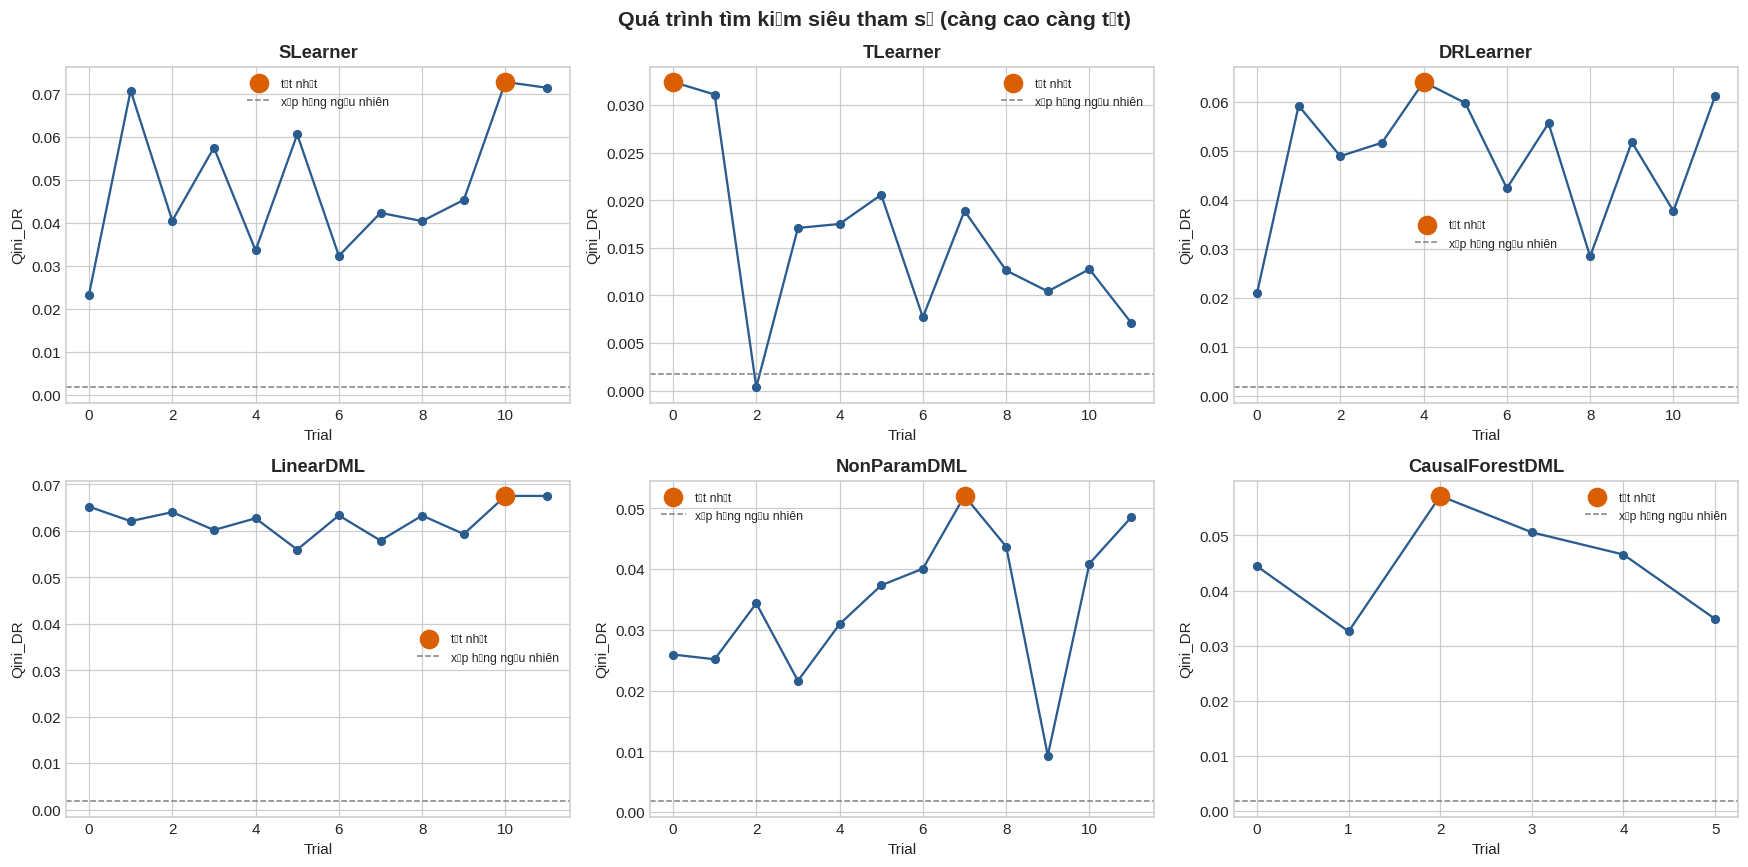

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, name in zip(axes.ravel(), MODELS):
    h = histories[name]
    ok = h[np.isfinite(h['dr_qini'])]
    ax.plot(ok['trial'], ok['dr_qini'], 'o-', color='#2b5c8f', ms=5)
    if len(ok):
        best_i = ok['dr_qini'].idxmax()
        ax.scatter(ok.loc[best_i, 'trial'], ok.loc[best_i, 'dr_qini'],
                   s=140, color='#d95f02', zorder=5, label='tốt nhất')
    ax.axhline(baseline_qini, color='gray', ls='--', lw=1, label='xếp hạng ngẫu nhiên')
    ax.set_title(name)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Qini_DR')
    ax.legend(fontsize=8)

plt.suptitle('Quá trình tìm kiếm siêu tham số (càng cao càng tốt)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '12_qua_trinh_tuning.png'), bbox_inches='tight')
plt.show()

### Bước 24 — Đối chiếu với thước đo cũ

Đây là chỗ trả lời câu *"đổi hàm mục tiêu thì được gì"* bằng số chứ không bằng lời.

Xếp hạng 6 mô hình theo hai thước đo rồi so tương quan hạng. Nếu DR-MSE thật sự chứa cùng thông tin với DR-AUUC thì hai bảng phải gần trùng nhau; nếu nó chỉ là nhiễu thì tương quan sẽ quanh 0 hoặc âm.

In [26]:
comp = summary.set_index('Mô hình')[['Qini_DR tốt nhất', 'DR-MSE tương ứng',
                                     'Policy value tương ứng']]

finite = np.isfinite(comp).all(axis=1)
failed_models = comp.index[~finite].tolist()
ok = comp[finite].copy()

if failed_models:
    print('!!! Không có trial nào thành công cho:', failed_models)
    print('    Phải sửa lỗi và chạy lại trước khi sang notebook 04.\n')

ok['Hạng theo Qini_DR'] = ok['Qini_DR tốt nhất'].rank(ascending=False).astype(int)
ok['Hạng theo DR-MSE'] = ok['DR-MSE tương ứng'].rank().astype(int)
ok['Hạng theo policy value'] = ok['Policy value tương ứng'].rank(ascending=False).astype(int)
display(ok.round(6))

if len(ok) >= 3:
    r_mse = ok['Hạng theo Qini_DR'].corr(ok['Hạng theo DR-MSE'], method='spearman')
    r_pv = ok['Hạng theo Qini_DR'].corr(ok['Hạng theo policy value'], method='spearman')
    print(f'Tương quan hạng Qini_DR vs DR-MSE       : {r_mse:+.2f}')
    print(f'Tương quan hạng Qini_DR vs policy value : {r_pv:+.2f}')
    print()
    print(f'Biên độ Qini_DR giữa 6 mô hình : '
          f'{ok["Qini_DR tốt nhất"].max() - ok["Qini_DR tốt nhất"].min():.4f}')
    print(f'Biên độ DR-MSE giữa 6 mô hình  : '
          f'{ok["DR-MSE tương ứng"].max() - ok["DR-MSE tương ứng"].min():.6f}'
          f'  (so với mốc hằng số {baseline_mse:.6f})')
    if r_mse <= 0:
        print('\n=> Hai thước đo xếp hạng ngược nhau. Đây chính là biểu hiện của lỗi đã nêu ở đầu')
        print('   notebook: DR-MSE bị số hạng phương sai hằng số của Ỹ nuốt mất phần tín hiệu,')
        print('   nên thứ hạng nó cho ra không mang thông tin về chất lượng xếp hạng.')

,Qini_DR tốt nhất,DR-MSE tương ứng,Policy value tương ứng,Hạng theo Qini_DR,Hạng theo DR-MSE,Hạng theo policy value
Mô hình,,,,,,
SLearner,0.072704,0.040539,0.018824,1,4,1
LinearDML,0.067536,0.040484,0.015244,2,1,2
DRLearner,0.064088,0.040857,0.014222,3,5,4
CausalForestDML,0.057165,0.040487,0.013357,4,2,5
NonParamDML,0.052029,0.040516,0.014263,5,3,3
TLearner,0.032424,0.041442,0.011112,6,6,6


Tương quan hạng Qini_DR vs DR-MSE       : +0.37
Tương quan hạng Qini_DR vs policy value : +0.83

Biên độ Qini_DR giữa 6 mô hình : 0.0403
Biên độ DR-MSE giữa 6 mô hình  : 0.000959  (so với mốc hằng số 0.040503)


---
# Phần 5 — Khoảng tin cậy bootstrap và quy tắc tuyên bố

Bảng ở Bước 22 sắp được 6 mô hình theo thứ tự, và luôn sắp được — chỉ cần sort là có. Câu hỏi khoa học thì khác: **chênh lệch đó có vượt được nhiễu không?**

Không có phần này thì cả notebook chỉ đang nói *"mô hình A có con số lớn hơn mô hình B"*, một phát biểu gần như vô nghĩa khi tín hiệu trong bộ dữ liệu yếu như ở đây.

### Quy tắc chốt cho toàn bộ đề tài

> **Chỉ tuyên bố A hơn B khi khoảng tin cậy bootstrap 95% của *hiệu* $\text{Qini}_{DR}(A) - \text{Qini}_{DR}(B)$ không chứa 0.**
>
> Nếu khoảng đó chứa 0 thì phát biểu đúng là *"hai phương pháp không khác biệt có ý nghĩa thống kê trên tập Val này"* — một kết luận nghiên cứu hợp lệ, và trung thực hơn hẳn việc tuyên bố quán quân dựa trên chữ số thứ ba.

### Vì sao phải bootstrap **theo cặp**

Cách ngây thơ là tính khoảng tin cậy riêng cho từng mô hình rồi xem chúng có chồng lấn không. Cách đó **quá bảo thủ**: phần lớn dao động của cả hai đến từ việc mẫu Val bốc ra như thế nào, và phần đó tác động lên hai mô hình **giống hệt nhau**.

Bootstrap theo cặp khử được đúng phần đó: trong mỗi lần lấy mẫu lại, tính Qini_DR của cả hai mô hình trên **cùng một mẫu** rồi mới lấy hiệu. Dùng chung một danh sách chỉ số `idx_boot` cho mọi mô hình chính là chỗ thực thi điều này.

### Hai điều phải nhớ khi đọc kết quả phần này

- **Trần trên được tính lại trong từng lần lấy mẫu.** `dr_qini` tự tính lại mẫu số ở mỗi lần gọi, vì mẫu bootstrap có thành phần $\tilde Y$ khác mẫu gốc. Dùng chung một trần cố định sẽ làm khoảng tin cậy hẹp đi một cách giả tạo.
- **Lời nguyền của người thắng cuộc.** Mỗi mô hình ở đây là trial tốt nhất trong 12 lần thử, chọn theo chính thước đo này. Lấy cực đại của 12 ước lượng nhiễu thì kỳ vọng của nó cao hơn giá trị thật. Nên con số điểm trong bảng dưới đây **hơi lạc quan**, và đó là thêm một lý do để chỉ tin vào khoảng tin cậy của hiệu.

### Bước 25 — Khoảng tin cậy cho từng mô hình

Dùng lại mảng CATE của trial tốt nhất mà Bước 19 đã giữ, nên phần này không phải huấn luyện lại gì cả.

In [27]:
n_ov = len(dr_val)
rng_boot = np.random.RandomState(SEED)
idx_boot = [rng_boot.randint(0, n_ov, n_ov) for _ in range(N_BOOT)]

score_ngau_nhien = np.random.RandomState(SEED).randn(n_ov)
NHAN_NGAU_NHIEN = '— Ngẫu nhiên (mốc)'

diem = {k: v for k, v in best_cate.items() if v is not None}
diem[NHAN_NGAU_NHIEN] = score_ngau_nhien

t0 = time.time()
boot_q = {}
for name, s in diem.items():
    boot_q[name] = np.array([dr_qini(s[i], dr_val[i]) for i in idx_boot])
print(f'Bootstrap {N_BOOT:,} lần × {len(diem)} mô hình: {time.time()-t0:.1f} giây\n')


def fmt_ci(goc, lo, hi, nhan=4):
    return f'{goc:+.{nhan}f} [{lo:+.{nhan}f} – {hi:+.{nhan}f}]'


rows = []
for name, s in diem.items():
    v = boot_q[name]
    lo, hi = np.percentile(v, [2.5, 97.5])
    rows.append({'Mô hình': name,
                 'Qini_DR': dr_qini(s), 'lo': lo, 'hi': hi,
                 'Hơn ngẫu nhiên': bool(lo > 0),
                 'Policy value@20%': dr_policy_value(s)})

df_boot = (pd.DataFrame(rows)
             .sort_values('Qini_DR', ascending=False)
             .reset_index(drop=True))

display(pd.DataFrame({
    'Mô hình': df_boot['Mô hình'],
    'Qini_DR [KTC 95%]': [fmt_ci(r.Qini_DR, r.lo, r.hi) for r in df_boot.itertuples()],
    'KTC không chứa 0': df_boot['Hơn ngẫu nhiên'],
    'Policy value@20%': df_boot['Policy value@20%'].round(5),
}))

n_hon = int(df_boot[df_boot['Mô hình'] != NHAN_NGAU_NHIEN]['Hơn ngẫu nhiên'].sum())
print(f'{n_hon}/{len(OK_MODELS)} mô hình có khoảng tin cậy tách hẳn khỏi 0.')

Bootstrap 1,000 lần × 7 mô hình: 173.4 giây



,Mô hình,Qini_DR [KTC 95%],KTC không chứa 0,Policy value@20%
0,SLearner,+0.0727 [+0.0513 – +0.0943],True,0.01882
1,LinearDML,+0.0675 [+0.0487 – +0.0875],True,0.01524
2,DRLearner,+0.0641 [+0.0441 – +0.0861],True,0.01422
3,CausalForestDML,+0.0572 [+0.0372 – +0.0775],True,0.01336
4,NonParamDML,+0.0520 [+0.0323 – +0.0745],True,0.01426
5,TLearner,+0.0324 [+0.0115 – +0.0536],True,0.01111
6,— Ngẫu nhiên (mốc),+0.0097 [-0.0084 – +0.0292],False,0.00334


6/6 mô hình có khoảng tin cậy tách hẳn khỏi 0.


### Bước 26 — So sánh theo cặp với mô hình đứng đầu

Đây là chỗ áp quy tắc đã phát biểu ở đầu Phần 5.

Hai cột kết quả, đừng gộp làm một:

| Cột | Phép thử | Nghĩa |
|---|---|---|
| `KTC khác 0` | hai phía | khoảng tin cậy của hiệu tách hẳn khỏi 0 — hai mô hình **khác nhau** có ý nghĩa |
| `Dẫn đầu thắng` | một phía | cả khoảng nằm **trên** 0 — mô hình dẫn đầu **hơn** đối thủ |

Con số "vượt trội so với n/N đối thủ" phải đếm bằng cột thứ hai. Đếm bằng cột thứ nhất thì một đối thủ *mạnh hơn* cũng bị cộng vào như thắng — ở đây không xảy ra vì mô hình dẫn đầu là mô hình có điểm cao nhất, nhưng đó là chuyện của luật chọn hiện tại chứ không phải của công thức.

In [28]:
dan_dau = df_boot[df_boot['Mô hình'] != NHAN_NGAU_NHIEN].iloc[0]['Mô hình']
print(f'Qini_DR điểm cao nhất: {dan_dau}\n')

so_sanh = []
for name in df_boot['Mô hình']:
    if name == dan_dau:
        continue
    hieu = boot_q[dan_dau] - boot_q[name]
    lo, hi = np.percentile(hieu, [2.5, 97.5])
    so_sanh.append({'Đối thủ': name, 'Chênh lệch Qini_DR': float(hieu.mean()),
                    'KTC thấp': float(lo), 'KTC cao': float(hi),
                    # Hai phía: khoảng tin cậy có tách khỏi 0 không.
                    'KTC khác 0': bool(lo > 0 or hi < 0),
                    # Một phía: chỉ khi CẢ khoảng nằm trên 0 mới là "dẫn đầu hơn đối thủ".
                    'Dẫn đầu thắng': bool(lo > 0)})

df_ss = pd.DataFrame(so_sanh)
display(df_ss.round(4))

doi_thu = df_ss[df_ss['Đối thủ'] != NHAN_NGAU_NHIEN]

# "Khoảng tin cậy khác 0" là phép thử HAI phía, còn "vượt trội" là một phía. Đếm bằng
# cột hai phía thì một đối thủ MẠNH HƠN cũng bị cộng vào như thắng. Ở đây mô hình dẫn
# đầu là mô hình có điểm cao nhất nên n_thua luôn bằng 0; dòng cảnh báo bên dưới để nếu
# có ngày luật chọn đổi mà nó nổ thì biết ngay, thay vì để con số sai chảy vào báo cáo.
n_thang = int(doi_thu['Dẫn đầu thắng'].sum())
n_thua = int((doi_thu['KTC cao'] < 0).sum())

print(f'\n{dan_dau} vượt trội có ý nghĩa thống kê so với {n_thang}/{len(doi_thu)} đối thủ.')
if n_thua:
    print(f'>>> BẤT THƯỜNG: {dan_dau} THUA có ý nghĩa {n_thua} đối thủ '
          '— kiểm lại cách chọn mô hình dẫn đầu <<<')
if n_thang == 0:
    print('=> Không mô hình nào tách khỏi phần còn lại trên tập Val.')
    print('   Phát biểu trung thực: các phương pháp KHÔNG khác biệt có ý nghĩa thống kê ở đây.')
    print('   Vẫn giữ đủ 6 bộ tham số để notebook 04 đấu tiếp trên tập RCT.')
else:
    print('=> Có tách biệt thật sự trên tập Val. Nhưng đây MỚI CHỈ LÀ VÙNG OVERLAP CỦA VAL:')
    print('   quyết định quán quân vẫn thuộc về Qini đo trên rct_select ở notebook 04.')

Qini_DR điểm cao nhất: SLearner



,Đối thủ,Chênh lệch Qini_DR,KTC thấp,KTC cao,Khác 0
0,LinearDML,0.0054,-0.0139,0.0269,False
1,DRLearner,0.0081,-0.0111,0.0279,False
2,CausalForestDML,0.0157,-0.0015,0.0334,False
3,NonParamDML,0.0205,-0.0011,0.0398,False
4,TLearner,0.0412,0.0162,0.0668,True
5,— Ngẫu nhiên (mốc),0.0637,0.0345,0.0906,True



SLearner vượt trội có ý nghĩa thống kê so với 1/5 đối thủ.
=> Có tách biệt thật sự trên tập Val. Nhưng đây MỚI CHỈ LÀ VÙNG OVERLAP CỦA VAL:
   quyết định quán quân vẫn thuộc về Qini đo trên rct_select ở notebook 04.


### Bước 27 — Biểu đồ

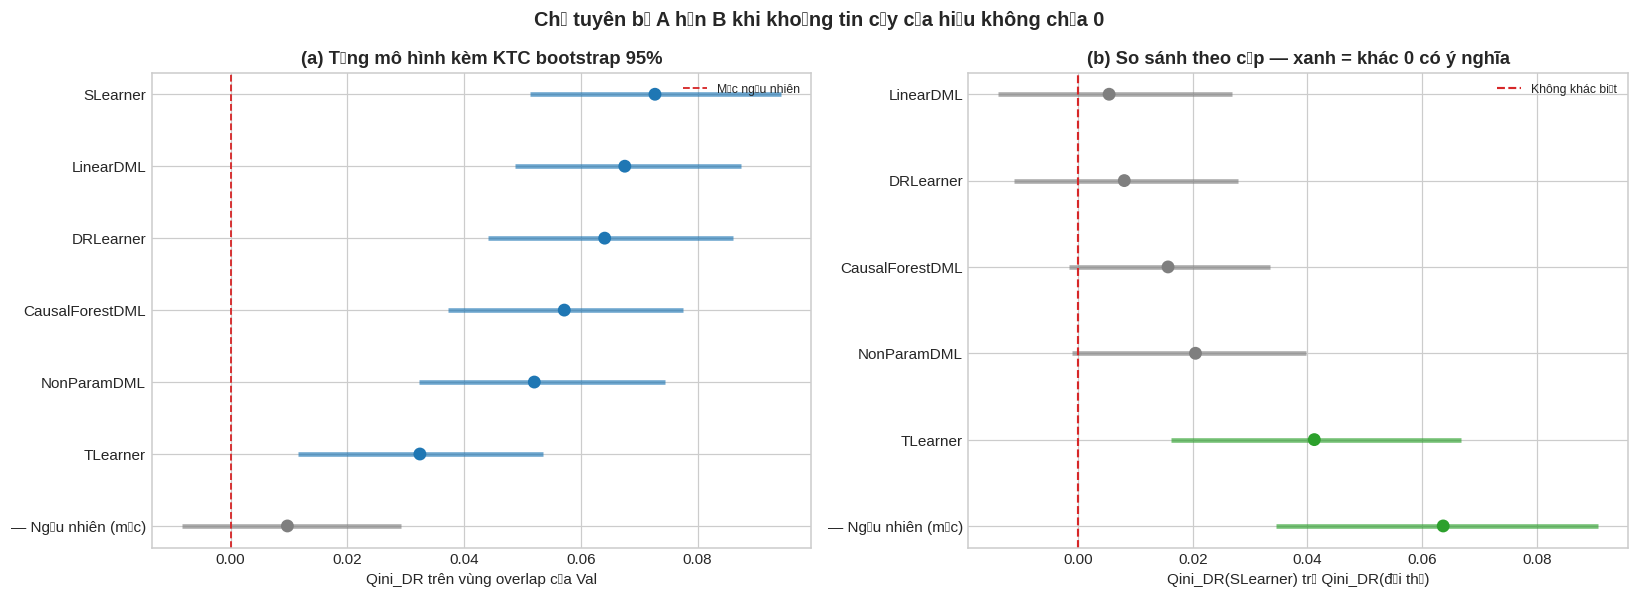

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

dfp = df_boot.iloc[::-1]
ypos = np.arange(len(dfp))
mau = ['#7f7f7f' if m == NHAN_NGAU_NHIEN else '#1f77b4' for m in dfp['Mô hình']]
axes[0].hlines(ypos, dfp['lo'], dfp['hi'], color=mau, lw=3, alpha=0.65)
axes[0].scatter(dfp['Qini_DR'], ypos, color=mau, s=55, zorder=5)
axes[0].axvline(0, color='#d62728', ls='--', lw=1.2, label='Mức ngẫu nhiên')
axes[0].set_yticks(ypos)
axes[0].set_yticklabels(dfp['Mô hình'])
axes[0].set_xlabel('Qini_DR trên vùng overlap của Val')
axes[0].set_title('(a) Từng mô hình kèm KTC bootstrap 95%')
axes[0].legend(fontsize=8)

dfd = df_ss.iloc[::-1]
ypos2 = np.arange(len(dfd))
def mau_so_sanh(r):
    if r['KTC cao'] < 0:
        return '#d62728'          # dẫn đầu THUA có ý nghĩa
    if r['Dẫn đầu thắng']:
        return '#2ca02c'          # dẫn đầu thắng có ý nghĩa
    return '#7f7f7f'              # chưa phân biệt được


mau2 = [mau_so_sanh(r) for _, r in dfd.iterrows()]
axes[1].hlines(ypos2, dfd['KTC thấp'], dfd['KTC cao'], color=mau2, lw=3, alpha=0.65)
axes[1].scatter(dfd['Chênh lệch Qini_DR'], ypos2, color=mau2, s=55, zorder=5)
axes[1].axvline(0, color='#d62728', ls='--', lw=1.4, label='Không khác biệt')
axes[1].set_yticks(ypos2)
axes[1].set_yticklabels(dfd['Đối thủ'])
axes[1].set_xlabel(f'Qini_DR({dan_dau}) trừ Qini_DR(đối thủ)')
axes[1].set_title('(b) So sánh theo cặp — xanh: dẫn đầu thắng · '
                  'đỏ: dẫn đầu thua · xám: chưa phân biệt được')
axes[1].legend(fontsize=8)

plt.suptitle('Chỉ tuyên bố A hơn B khi khoảng tin cậy của hiệu không chứa 0',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '12b_bootstrap_so_sanh.png'), bbox_inches='tight')
plt.show()

---
# Phần 6 — Mô hình có mang sang được môi trường RCT không?

Phần 2 mới chỉ cho thấy hiệu chỉnh doubly robust **làm đổi** con số ước lượng. Nó chưa nói được con số đã hiệu chỉnh có đáng tin hay không, vì trên dữ liệu quan sát ta không có gì để đối chiếu.

Chỗ duy nhất có sự thật là **dữ liệu RCT**. Nhưng phải so cho đúng cách.

### Cái bẫy: so nhầm hai đại lượng khác nhau

Cách so ngây thơ là lấy ước lượng DR trên tập Val rồi đặt cạnh ATE đo từ RCT. Cách đó **sai**, vì hai vế nhắm vào hai đại lượng khác nhau:

$$\underbrace{E_{P_{val}}[\tau(X)]}_{\text{DR trên Val}} \qquad \text{so với} \qquad \underbrace{E_{P_{rct}}[\tau(X)]}_{\text{ATE trên RCT}}$$

Hai đại lượng này chỉ bằng nhau khi $\tau(x)$ là hằng số, hoặc khi hai tập có cùng phân phối đặc trưng. Mà notebook 01 đã chứng minh **cả hai điều đều sai**: uplift chênh nhau vài lần giữa các phân khúc, và có dịch chuyển phân phối rõ rệt giữa hai môi trường.

Sau Bước 10 thì khoảng cách còn xa thêm một bậc nữa: ước lượng DR bây giờ sống trên *vùng overlap* của Val, hẹp hơn cả $P_{val}$.

### Cách so đúng

Đưa cả hai vế về cùng một quần thể — quần thể của tập RCT:

1. Huấn luyện mô hình CATE trên **dữ liệu quan sát**
2. Dự đoán $\hat\tau(x)$ trên **đặc trưng của tập rct_select**
3. Lấy trung bình — được ước lượng cho $E_{P_{rct}}[\tau(X)]$
4. So với hiệu hai tỉ lệ chuyển đổi tính trên **chính tập rct_select đó**

Giờ hai vế cùng một estimand, và cả hai đều nằm trên toàn bộ quần thể RCT — việc trim ở Phần 2 không đụng tới phép so này, vì nó chỉ áp cho thước đo trên Val. Đây là phép kiểm **transportability**: mô hình học từ môi trường có thiên vị có dự báo đúng được hiệu ứng ở môi trường ngẫu nhiên hóa không.

Trên tập RCT việc phát voucher là ngẫu nhiên nên $e \equiv 0{,}5$ — không có vấn đề overlap nào để xử lý ở đây.

Dùng `rct_select`. Tập `rct_holdout` vẫn niêm phong tới notebook 04.

### Bước 28 — Nạp tập rct_select

In [30]:
rct = pd.read_parquet(os.path.join(DATA_DIR, 'rct_select.parquet'))

X_rct = rct[FEATS].values.astype(np.float64)
W_rct = rct['is_treat'].values
Y_rct = rct['label'].values

print(f'rct_select: {len(rct):,} dòng | treat {W_rct.mean()*100:.2f}% '
      f'| mua {Y_rct.mean()*100:.2f}%')

rct_select: 90,834 dòng | treat 52.12% | mua 3.52%


### Bước 29 — Huấn luyện DR-Learner với tham số tốt nhất rồi mang sang RCT

In [31]:
dr_best_params = studies['DRLearner'].best_params
print('Tham số dùng:', dr_best_params)

model_transport = build_model('DRLearner', dr_best_params).fit(X_tune, W_tune, Y_tune)
tau_rct = model_transport.predict_cate(X_rct)

# Vế 1 — ước lượng mang sang: trung bình CATE dự đoán trên covariate của RCT
ate_transported = tau_rct.mean()
se_transported = tau_rct.std() / np.sqrt(len(tau_rct))

# Vế 2 — sự thật đo trực tiếp trên chính tập đó
p1, n1 = Y_rct[W_rct == 1].mean(), (W_rct == 1).sum()
p0, n0 = Y_rct[W_rct == 0].mean(), (W_rct == 0).sum()
ate_rct_sel = p1 - p0
se_rct_sel = np.sqrt(p1 * (1 - p1) / n1 + p0 * (1 - p0) / n0)

display(pd.DataFrame([
    ('Mang sang từ dữ liệu quan sát', ate_transported * 100,
     (ate_transported - 1.96 * se_transported) * 100,
     (ate_transported + 1.96 * se_transported) * 100),
    ('Đo trực tiếp trên rct_select', ate_rct_sel * 100,
     (ate_rct_sel - 1.96 * se_rct_sel) * 100,
     (ate_rct_sel + 1.96 * se_rct_sel) * 100),
], columns=['Ước lượng', 'ATE (pp)', 'KTC dưới', 'KTC trên']).round(3))

Tham số dùng: {'n_estimators': 200, 'learning_rate': 0.04141536110538596, 'max_depth': 5, 'min_child_samples': 38}


,Ước lượng,ATE (pp),KTC dưới,KTC trên
0,Mang sang từ dữ liệu quan sát,1.256,1.230,1.281
1,Đo trực tiếp trên rct_select,0.372,0.132,0.611


### Bước 30 — Kiểm định trên hiệu hai ước lượng

Cả hai vế đều là **ước lượng có sai số**, không vế nào là chân lý. Nên phép kiểm phải đặt trên hiệu của chúng, với sai số chuẩn gộp:

$$\text{diff} = \hat\tau_{\text{mang sang}} - \hat\tau_{\text{RCT}}, \qquad SE_{\text{diff}} = \sqrt{SE_1^2 + SE_2^2}$$

Hai ước lượng tính trên hai tập dữ liệu tách rời nhau nên cộng phương sai là hợp lệ.

In [32]:
diff = ate_transported - ate_rct_sel
se_diff = np.sqrt(se_transported ** 2 + se_rct_sel ** 2)
mdd = 1.96 * se_diff                      # chênh lệch nhỏ nhất phát hiện được

print(f'Chênh lệch          : {diff*100:+.3f} pp')
print(f'KTC 95% của chênh lệch: [{(diff-mdd)*100:+.3f} ; {(diff+mdd)*100:+.3f}] pp')
print()
if abs(diff) <= mdd:
    print('=> Chênh lệch KHÔNG có ý nghĩa thống kê.')
    print('   Mô hình mang sang môi trường RCT mà không lệch phát hiện được.')
else:
    print('=> Chênh lệch CÓ ý nghĩa thống kê.')
    print('   Mô hình lệch khi mang sang RCT — có thể do unconfoundedness không thỏa,')
    print('   do mô hình phụ ước lượng kém, hoặc do dịch chuyển phân phối quá mạnh.')

Chênh lệch          : +0.884 pp
KTC 95% của chênh lệch: [+0.643 ; +1.125] pp

=> Chênh lệch CÓ ý nghĩa thống kê.
   Mô hình lệch khi mang sang RCT — có thể do unconfoundedness không thỏa,
   do mô hình phụ ước lượng kém, hoặc do dịch chuyển phân phối quá mạnh.


### Bước 31 — Phép kiểm này mạnh tới đâu?

Một phép kiểm "đạt" chỉ có ý nghĩa nếu nó **đủ sức phát hiện sai lệch khi sai lệch tồn tại**. Nếu khoảng tin cậy rộng hơn cả đại lượng đang đo thì "đạt" gần như không nói lên điều gì.

Nên in thẳng ra giới hạn đó thay vì để người đọc tự đoán.

In [33]:
print(f'Chênh lệch nhỏ nhất phát hiện được : {mdd*100:.3f} pp')
print(f'Bản thân ATE chỉ có               : {ate_rct_sel*100:.3f} pp')
print(f'Tỉ lệ                             : {mdd/abs(ate_rct_sel):.1f} lần ATE')
print()
if mdd > abs(ate_rct_sel):
    print('=> Phép kiểm YẾU: chỉ phát hiện được sai lệch lớn hơn cả chính hiệu ứng.')
    print('   Nó bác bỏ được ước lượng ngây thơ, nhưng không đủ sức khẳng định')
    print('   mô hình không chệch. Cần nêu rõ giới hạn này khi báo cáo.')
else:
    print('=> Phép kiểm đủ nhạy để phát hiện sai lệch cỡ ATE.')

print()
print('Ba giới hạn cần nhớ khi diễn giải kết quả này:')
print('  1. Sai số của vế mang sang mới chỉ tính biến thiên do lấy mẫu covariate,')
print('     chưa tính sai số ước lượng của chính mô hình -> khoảng tin cậy thật còn rộng hơn.')
print('  2. Phép kiểm đạt KHÔNG chứng minh unconfoundedness — giả định đó')
print('     về bản chất không kiểm chứng được từ dữ liệu.')
print('  3. Kết quả này tính trên rct_select, không phải rct_holdout.')

Chênh lệch nhỏ nhất phát hiện được : 0.241 pp
Bản thân ATE chỉ có               : 0.372 pp
Tỉ lệ                             : 0.6 lần ATE

=> Phép kiểm đủ nhạy để phát hiện sai lệch cỡ ATE.

Ba giới hạn cần nhớ khi diễn giải kết quả này:
  1. Sai số của vế mang sang mới chỉ tính biến thiên do lấy mẫu covariate,
     chưa tính sai số ước lượng của chính mô hình -> khoảng tin cậy thật còn rộng hơn.
  2. Phép kiểm đạt KHÔNG chứng minh unconfoundedness — giả định đó
     về bản chất không kiểm chứng được từ dữ liệu.
  3. Kết quả này tính trên rct_select, không phải rct_holdout.


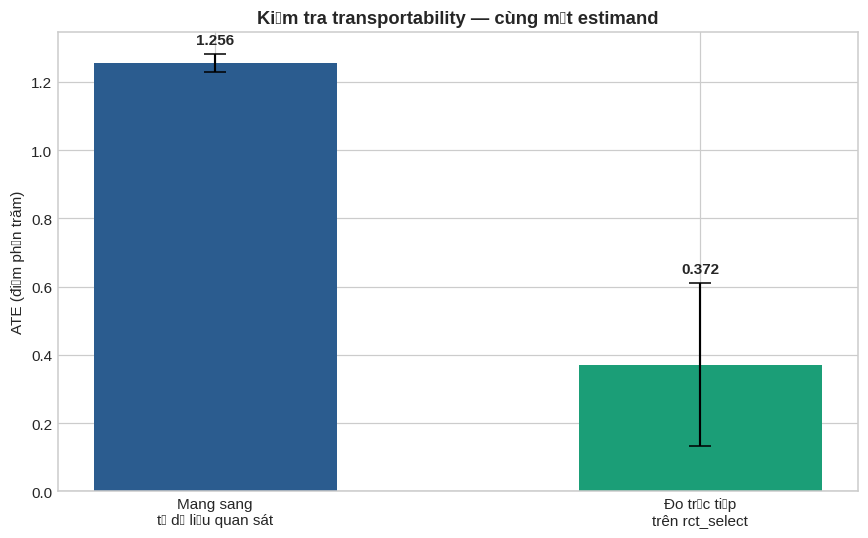

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
names = ['Mang sang\ntừ dữ liệu quan sát', 'Đo trực tiếp\ntrên rct_select']
vals = [ate_transported * 100, ate_rct_sel * 100]
errs = [1.96 * se_transported * 100, 1.96 * se_rct_sel * 100]

bars = ax.bar(names, vals, color=['#2b5c8f', '#1b9e77'], width=0.5)
ax.errorbar(range(2), vals, yerr=errs, fmt='none', ecolor='black', capsize=7, lw=1.4)
ax.axhline(0, color='gray', lw=0.8)
ax.set_ylabel('ATE (điểm phần trăm)')
ax.set_title('Kiểm tra transportability — cùng một estimand')
for i, (b, v, e) in enumerate(zip(bars, vals, errs)):
    ax.text(b.get_x() + b.get_width() / 2, v + e + 0.03,
            f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '13_kiem_tra_transportability.png'), bbox_inches='tight')
plt.show()

---
# Phần 7 — Chốt tham số và bàn giao

### Bước 32 — Bộ tham số tốt nhất của từng mô hình

In [35]:
best_params = {}
for name in MODELS:
    st = studies[name]
    ok_flag = np.isfinite(st.best_value)
    v = boot_q.get(name)
    lo, hi = (np.percentile(v, [2.5, 97.5]) if v is not None else (None, None))
    best_params[name] = {
        'params': st.best_params,
        'dr_qini': float(st.best_value) if ok_flag else None,
        'dr_qini_ci': [float(lo), float(hi)] if v is not None else None,
        'dr_mse': (float(histories[name].loc[histories[name]['dr_qini'].idxmax(), 'dr_mse'])
                   if ok_flag else None),
        'n_trials': len(st.trials),
        'thanh_cong': bool(ok_flag),
    }
    print(f'{name}:' + ('' if ok_flag else '   *** KHÔNG CÓ TRIAL NÀO THÀNH CÔNG ***'))
    for k, v_ in st.best_params.items():
        print(f'    {k:<24} = {v_}')
    if ok_flag:
        print(f'    -> Qini_DR = {st.best_value:+.4f} [{lo:+.4f} – {hi:+.4f}]\n')

n_fail = sum(1 for v in best_params.values() if not v['thanh_cong'])
print('=' * 62)
print(f'  {len(MODELS)-n_fail}/{len(MODELS)} mô hình có tham số dùng được')
if n_fail:
    print('  >>> Sửa lỗi rồi chạy lại trước khi sang notebook 04 <<<')
print('=' * 62)

SLearner:
    n_estimators             = 100
    learning_rate            = 0.026777926034348507
    max_depth                = 3
    min_child_samples        = 20
    -> Qini_DR = +0.0727 [+0.0513 – +0.0943]

TLearner:
    n_estimators             = 200
    learning_rate            = 0.13125830316209655
    max_depth                = 7
    min_child_samples        = 79
    -> Qini_DR = +0.0324 [+0.0115 – +0.0536]

DRLearner:
    n_estimators             = 200
    learning_rate            = 0.04141536110538596
    max_depth                = 5
    min_child_samples        = 38
    -> Qini_DR = +0.0641 [+0.0441 – +0.0861]

LinearDML:
    nuisance_n_estimators    = 300
    nuisance_max_depth       = 7
    cv                       = 3
    -> Qini_DR = +0.0675 [+0.0487 – +0.0875]

NonParamDML:
    n_estimators             = 100
    learning_rate            = 0.017001754132211097
    max_depth                = 3
    min_child_samples        = 42
    nuisance_n_estimators    = 150
    nuisanc

### Bước 33 — Ghi file bàn giao

Khối `xu_ly_overlap` là phần notebook 04 **bắt buộc** phải đọc: nó chứa `propensity_alpha`, ngưỡng mà DR-Learner ở notebook 04 phải dùng lại y hệt. Nếu hai notebook cắt $\hat e$ ở hai ngưỡng khác nhau thì bộ siêu tham số tinh chỉnh cho mô hình này lại đem áp cho một mô hình khác.

`cau_hinh.feature_names` ghi đủ 69 tên cột theo đúng thứ tự — notebook 04 và bộ test đối chiếu lại để chắc chắn ba nơi cùng nói về một tập đặc trưng.

In [36]:
output = {
    'run_mode': RUN_MODE,
    'canh_bao': ('KẾT QUẢ CHẾ ĐỘ THỬ NHANH — KHÔNG DÙNG ĐỂ BÁO CÁO'
                 if SMOKE_TEST else None),
    'ham_muc_tieu': {
        'ten': 'dr_qini',
        'mo_ta': ('DR-AUUC chuẩn hóa: sắp theo tau_hat, lấy trung bình tích lũy của '
                  'pseudo-outcome doubly robust, tính diện tích trên đường chéo, '
                  'chia cho diện tích của xếp hạng biết trước. Ngẫu nhiên ~ 0, biết trước = 1.'),
        'huong': 'maximize',
        'thay_the_cho': 'dr_mse',
        'ly_do_doi': ('DR-MSE = MSE thật + E[Var(Y_tilde|X)]; số hạng thứ hai là hằng số '
                      'giống nhau ở mọi mô hình nhưng lớn hơn số hạng thứ nhất vài trăm lần, '
                      'nên nó nuốt mất phần tín hiệu và Optuna chỉ đuổi theo nhiễu.'),
    },
    'cau_hinh': {
        'n_tune_rows': int(len(X_tune)),
        'n_val_rows': int(len(X_val)),
        'n_val_overlap_rows': int(len(X_val_ov)),
        'trial_moi_mo_hinh': TRIALS_PER_MODEL,
        'tong_trial': int(TONG_TRIAL),
        'n_bootstrap': N_BOOT,
        'n_features': len(FEATS),
        'feature_names': FEATS,
        'seed': SEED,
    },
    'xu_ly_overlap': {
        'propensity_alpha': float(E_ALPHA),
        'propensity_clip': [float(E_CLIP[0]), float(E_CLIP[1])],
        'alpha_crump_goc': float(a_crump),
        'hang_rao_alpha': [ALPHA_MIN, ALPHA_MAX],
        'trim_ap_dung_cho': 'thuoc_do_tren_val',
        'clip_ap_dung_cho': 'moi_cong_thuc_doubly_robust_ke_ca_khi_huan_luyen',
        'ti_le_val_giu_lai': float(overlap.mean()),
        'winsorize_phan_vi': [WINSOR_P, 100 - WINSOR_P],
        'winsorize_can': [WIN_LO, WIN_HI],
        'estimand': ('ATE trên vùng overlap: E_Pval[tau(X) | alpha <= e(X) <= 1-alpha]. '
                     'KHÔNG phải ATE trên toàn quần thể Val.'),
        'ghi_chu_notebook_04': ('Notebook 04 phải đọc propensity_alpha ở đây và dùng đúng '
                                'ngưỡng đó trong compute_dr_scores, nếu không thì bộ siêu '
                                'tham số tinh chỉnh cho mô hình này lại áp cho mô hình khác.'),
    },
    'hieu_chinh_tren_val': {
        'ate_ngay_tho_toan_val': float(ate_naive_all),
        'ate_ngay_tho_vung_overlap': float(ate_naive_ov),
        'ate_doubly_robust_toan_val': float(ate_dr_all),
        'ate_doubly_robust_vung_overlap': float(ate_dr),
        'se_ate_doubly_robust': float(se_dr),
        'qini_dr_ngau_nhien': float(baseline_qini),
        'dr_mse_du_doan_hang_so': float(baseline_mse),
        'ghi_chu': ('Mức ATE luôn lấy từ dr_ov (đã trim, CHƯA winsorize). dr_val đã winsorize '
                    'nên chỉ dùng làm nhãn cho thước đo xếp hạng, không dùng báo cáo mức.'),
    },
    'so_sanh_bootstrap_tren_val': {
        'mo_hinh_dan_dau': dan_dau,
        'quy_tac': 'Chỉ tuyên bố A hơn B khi KTC 95% của hiệu Qini_DR không chứa 0',
        'so_doi_thu_thua_co_y_nghia': int(n_thang),
        'so_doi_thu': int(len(doi_thu)),
        'chi_tiet': so_sanh,
    },
    'kiem_tra_transportability': {
        'ate_mang_sang': float(ate_transported),
        'se_mang_sang': float(se_transported),
        'ate_do_tren_rct_select': float(ate_rct_sel),
        'se_rct_select': float(se_rct_sel),
        'chenh_lech': float(diff),
        'se_chenh_lech': float(se_diff),
        'chenh_lech_nho_nhat_phat_hien_duoc': float(mdd),
        'co_y_nghia_thong_ke': bool(abs(diff) > mdd),
        'tap_dung': 'rct_select',
        'ghi_chu': 'Vế mang sang chưa tính sai số ước lượng của mô hình nên KTC thật còn rộng hơn',
    },
    'best_params': best_params,
    'thu_tu_theo_dr_qini': [m for m in df_boot['Mô hình'] if m != NHAN_NGAU_NHIEN],
}

# Chốt cổng trước khi ghi
assert output['cau_hinh']['n_features'] == 69
assert not any(c.startswith('fe_') for c in output['cau_hinh']['feature_names'])
assert set(output['best_params']) == set(MODELS)

path = os.path.join(ART_DIR, 'best_params.json')
with open(path, 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print('Đã ghi:', path)
print(f'  ham_muc_tieu    : dr_qini (maximize)')
print(f'  tổng trial      : {TONG_TRIAL}')
print(f'  n_features      : {len(FEATS)}')
print(f'  propensity_alpha: {E_ALPHA}  <- notebook 04 phải đọc con số này')
print(f'  estimand        : ATE trên vùng overlap ({overlap.mean()*100:.1f}% tập Val)')
if SMOKE_TEST:
    print('\n*** File này đang mang kết quả chế độ thử nhanh. ***')
    print('*** Chạy lại với SMOKE_TEST=0 trước khi dùng số cho báo cáo. ***')

Đã ghi: /kaggle/working/artifacts/best_params.json
  ham_muc_tieu    : dr_qini (maximize)
  tổng trial      : 66
  n_features      : 69
  propensity_alpha: 0.071  <- notebook 04 phải đọc con số này
  estimand        : ATE trên vùng overlap (43.4% tập Val)


### Bước 34 — Kiểm tra lại số run trên MLflow

In [37]:
runs = mlflow.search_runs(experiment_names=['lazada_cate_tuning'])

print(f'Tổng số run đã ghi: {len(runs)}')
if len(runs):
    # Gộp thêm theo tags.objective: database này còn giữ nguyên các run của bản
    # notebook trước (hàm mục tiêu DR-MSE, chưa có tag objective -> hiện là NaN).
    # Giữ lại chứ không xoá, vì đó chính là tang chứng cho lập luận ở Bước 24.
    if 'tags.objective' not in runs.columns:
        runs['tags.objective'] = np.nan
    cols = ['tags.model', 'tags.run_mode', 'tags.objective',
            'metrics.dr_qini', 'metrics.dr_mse', 'metrics.fit_seconds']
    cols = [c for c in cols if c in runs.columns]
    for c in ['metrics.dr_qini', 'metrics.dr_mse', 'metrics.fit_seconds']:
        if c not in runs.columns:
            runs[c] = np.nan
    bang_run = runs[cols].groupby(
        ['tags.objective', 'tags.model', 'tags.run_mode'], dropna=False).agg(
        so_run=('metrics.dr_mse', 'size'),
        dr_qini_tot_nhat=('metrics.dr_qini', 'max'),
        dr_mse_tot_nhat=('metrics.dr_mse', 'min'),
        giay_trung_binh=('metrics.fit_seconds', 'mean'),
    ).round(4)
    display(bang_run)
    print('\nDòng có tags.objective = NaN là run của bản notebook trước (hàm mục tiêu DR-MSE).')

Tổng số run đã ghi: 66


so_run  dr_qini_tot_nhat  dr_mse_tot_nhat  giay_trung_binh
tags.objective tags.model      tags.run_mode                                                            
dr_qini        CausalForestDML full                6            0.0572           0.0405         346.8598
               DRLearner       full               12            0.0641           0.0405          51.1574
               LinearDML       full               12            0.0675           0.0405          33.7324
               NonParamDML     full               12            0.0520           0.0405          34.2504
               SLearner        full               12            0.0727           0.0405           5.4829
               TLearner        full               12            0.0324           0.0407           6.2606


Dòng có tags.objective = NaN là run của bản notebook trước (hàm mục tiêu DR-MSE).


In [38]:
print('=' * 68)
print('  TÓM TẮT NOTEBOOK 03'.center(68))
print('=' * 68)
print(f'Chế độ chạy              : {RUN_MODE}')
print(f'Số đặc trưng             : {len(FEATS)} (cột gốc, không có fe_*)')
print(f'Tổng trial đã chạy       : {SO_TRIAL_DA_CHAY}')
print(f'Ngưỡng overlap (Crump)   : alpha = {E_ALPHA}  '
      f'(giá trị gốc {a_crump:.4f})')
print(f'Val giữ lại sau trim     : {len(dr_val):,}/{len(dr_full):,} dòng '
      f'({overlap.mean()*100:.1f}%)')
print(f'Winsorize                : {WINSOR_P}% / {100-WINSOR_P}% '
      f'-> cận [{WIN_LO:.3f} ; {WIN_HI:.3f}]')
print(f'Estimand của thước đo    : ATE trên vùng overlap của Val')
print()
print(f'ATE ngây thơ (overlap)   : {ate_naive_ov*100:+.3f} pp')
print(f'ATE doubly robust        : {ate_dr*100:+.3f} pp '
      f'[{(ate_dr-1.96*se_dr)*100:+.3f} ; {(ate_dr+1.96*se_dr)*100:+.3f}]')
print()
print('Xếp hạng theo Qini_DR (thước đo mới):')
for _, r in df_boot.iterrows():
    dau = '   <- KTC không chứa 0' if r['Hơn ngẫu nhiên'] else ''
    print(f"  {r['Mô hình']:<22} {fmt_ci(r['Qini_DR'], r['lo'], r['hi'])}{dau}")
print()
print(f'Mô hình dẫn đầu          : {dan_dau}')
print(f'  vượt có ý nghĩa        : {n_thang}/{len(doi_thu)} đối thủ')
print()
print(f'Transportability sang RCT: chênh lệch {diff*100:+.3f} pp, '
      f'ngưỡng phát hiện {mdd*100:.3f} pp '
      f'-> {"CÓ" if abs(diff) > mdd else "KHÔNG"} ý nghĩa thống kê')
print('=' * 68)
if SMOKE_TEST:
    print('>>> ĐANG Ở CHẾ ĐỘ SMOKE TEST — mọi con số ở trên chỉ để kiểm tra pipeline <<<')

                         TÓM TẮT NOTEBOOK 03                        
Chế độ chạy              : full
Số đặc trưng             : 69 (cột gốc, không có fe_*)
Tổng trial đã chạy       : 66
Ngưỡng overlap (Crump)   : alpha = 0.071  (giá trị gốc 0.0709)
Val giữ lại sau trim     : 43,431/100,000 dòng (43.4%)
Winsorize                : 0.5% / 99.5% -> cận [-1.258 ; 1.548]
Estimand của thước đo    : ATE trên vùng overlap của Val

ATE ngây thơ (overlap)   : +1.998 pp
ATE doubly robust        : +0.444 pp [+0.093 ; +0.795]

Xếp hạng theo Qini_DR (thước đo mới):
  SLearner               +0.0727 [+0.0513 – +0.0943]   <- KTC không chứa 0
  LinearDML              +0.0675 [+0.0487 – +0.0875]   <- KTC không chứa 0
  DRLearner              +0.0641 [+0.0441 – +0.0861]   <- KTC không chứa 0
  CausalForestDML        +0.0572 [+0.0372 – +0.0775]   <- KTC không chứa 0
  NonParamDML            +0.0520 [+0.0323 – +0.0745]   <- KTC không chứa 0
  TLearner               +0.0324 [+0.0115 – +0.0536]   <- KTC không 

---
## Kết luận

### Đã làm

| Việc | Kết quả |
|---|---|
| Xử lý overlap | Ngưỡng trim tự tính theo quy tắc Crump (2009), không gõ tay; kèm bảng độ nhạy và biểu đồ phân phối $\hat e$ |
| Winsorize | Phân vị 0,5% / 99,5%, tách bạch vai trò `dr_ov` (báo cáo mức) và `dr_val` (nhãn xếp hạng) |
| Thước đo tinh chỉnh | DR-AUUC chuẩn hóa, qua bốn phép kiểm chứng có `assert` chốt cổng |
| Tinh chỉnh | 6 mô hình × Optuna, **66 trial** ở chế độ đầy đủ (12 mỗi mô hình, 6 cho CausalForest), hướng `maximize` |
| Đặc trưng | Đúng 69 cột gốc từ `feature_info.json`, có `assert` chặn cột `fe_*` |
| Khoảng tin cậy | Bootstrap theo cặp cho mọi so sánh giữa các mô hình |
| Kiểm tra transportability | So cùng estimand trên `rct_select`, kiểm định trên hiệu, có báo độ nhạy |
| Ghi vết | Toàn bộ trial lên MLflow kèm cả bốn thước đo |
| Bàn giao | `artifacts/best_params.json` |

### Bốn thay đổi ở khâu tinh chỉnh, và mỗi cái sửa được gì

1. **Hàm mục tiêu đổi sang DR-AUUC.** Với DR-MSE, sáu mô hình cho ra sáu con số chụm vào nhau ở chữ số thứ tư quanh chính mốc "dự đoán một hằng số" — thứ hạng khi đó không mang thông tin. Bước 24 in ra tương quan hạng giữa hai thước đo để thấy chuyện đó bằng số ngay trên lần chạy hiện tại.

2. **Winsorize 0,5% / 99,5%.** Chặn chuyện một dòng đơn lẻ quyết định thứ hạng của cả mô hình. Cái giá phải trả — trung bình bị kéo lệch — được in thẳng ở Bước 11 và xử lý bằng cách tách hai biến cho hai mục đích khác nhau.

3. **Trim thay vì chỉ nâng ngưỡng cắt.** Đổi lại estimand hẹp đi, và Bước 10 phát biểu lại estimand đó ở dạng công thức chứ không nói chung chung. Đây là thay đổi có hệ quả xa nhất trong bốn cái: **mọi con số ở Phần 2, 4, 5 đều thuộc về vùng overlap**, không phải toàn bộ Val.

4. **Bootstrap theo cặp.** Biến bảng xếp hạng từ *"mô hình A có số lớn hơn"* thành một phát biểu kiểm chứng được. Quy tắc: chỉ tuyên bố A hơn B khi khoảng tin cậy 95% của hiệu không chứa 0.

### Con số của lần chạy hiện tại

Không chép cứng con số nào vào đây. Ô lệnh tóm tắt ngay phía trên in ra toàn bộ kết quả của **lần chạy hiện tại**, và bản đầy đủ nằm trong `artifacts/best_params.json` kèm trường `run_mode`.

> Đọc `run_mode` trước khi trích bất kỳ con số nào. `smoke_test` nghĩa là 11 trial trên 20 nghìn dòng — đủ để biết pipeline không lỗi, **không đủ để kết luận gì** về mô hình.

### Điều quan trọng nhất rút ra

Phần 6 là bằng chứng thực nghiệm cho luận điểm của đề tài, và phải phát biểu **đúng phạm vi** của nó. Nếu phép kiểm transportability **không đạt** thì đó là kết quả quan trọng chứ không phải thất bại cần giấu: nó là bằng chứng trực tiếp cho thấy hiệu chỉnh doubly robust trên bộ dữ liệu này chưa khử hết thiên vị chọn lọc, nguyên nhân hợp lý nhất là giả định unconfoundedness không thỏa mãn hoàn toàn — vẫn còn confounder không quan sát được mà 69 đặc trưng trong dữ liệu không bắt được. Hệ quả cho notebook 04: mọi ước lượng CATE học từ dữ liệu quan sát đều mang theo phần thiên vị đó, và đó chính là lý do khâu đánh giá cuối **bắt buộc** phải làm trên tập RCT.

Phát biểu **không** được:

- *"Đã chứng minh pseudo-outcome không chệch"* — phép kiểm chỉ phát hiện được sai lệch lớn hơn ngưỡng in ra ở Bước 31.
- *"Đã kiểm chứng giả định unconfoundedness"* — giả định đó không kiểm chứng được từ dữ liệu.
- *"Ước lượng DR trên Val gần với sự thật hơn ước lượng ngây thơ"* — hai vế đó khác estimand.
- *"Mô hình X là tốt nhất"* dựa trên bảng Bước 22 — chỉ được nói vậy khi Bước 26 cho thấy khoảng tin cậy của hiệu không chứa 0, và kể cả khi đó thì mới chỉ đúng **trên vùng overlap của Val**.

### Lưu ý cho notebook 04

- Notebook 04 **phải đọc `xu_ly_overlap.propensity_alpha`** từ `best_params.json` và dùng đúng ngưỡng đó trong `compute_dr_scores`.
- Qini_DR chỉ dùng để **chọn siêu tham số**. Quyết định mô hình nào thắng dựa trên **Qini đo trên tập RCT**, nơi việc phát voucher là ngẫu nhiên nên không cần trim gì cả.
- Tham số tìm được trên mẫu con — notebook 04 sẽ huấn luyện lại trên **toàn bộ** Train + Val.
- Kiểm tra `run_mode` trong `best_params.json` phải là `full` trước khi dùng cho báo cáo.

### Notebook tiếp theo

`04_benchmark_evaluation.ipynb` — xây bộ metric cho tập RCT kèm bốn phép kiểm chứng, huấn luyện lại 6 mô hình bằng tham số tốt nhất, chọn quán quân trên `rct_select`, khóa mọi quyết định, rồi đánh giá lần cuối trên `rct_holdout`.